# TTA-UC現象のGKSL-Lindblad量子ダイナミクス：包括的比較

このノートブックでは、TTA-UC（Triplet-Triplet Annihilation Upconversion）現象の
GKSL-Lindblad量子ダイナミクスシミュレーションを複数のシナリオで実行し、結果を比較します。

## シナリオ一覧

| シナリオ | 手法 | ボソン | シミュレーション方式 | シミュレータ |
|----------|------|--------|---------------------|------------|
| 1 | 古典ODE (RK45) | なし | 密度行列ODE | ClassicalGKSLSimulator |
| 2 | 古典ODE (BDF) | あり | 密度行列ODE | ClassicalGKSLBosonSimulator |
| 3 | Qubit Stinespring+Trotter | なし | **密度行列（Statevector）** | QubitGKSLSimulator |
| 3b | Qubit Stinespring+Trotter | なし | **ショットベース** | QubitGKSLShotSimulator |
| 3c | Qubit Stinespring+Trotter | なし | **ショットベース+ノイズ** | QubitGKSLNoisyShotSimulator |
| 4 | Qubit Stinespring+Trotter | あり | 密度行列（Statevector） | QubitGKSLBosonSimulator |
| 5 | Qudit Stinespring+Trotter | なし | **密度行列（Statevector）** | QuditGKSLSimulator |
| 5b | Qudit Stinespring+Trotter | なし | **ショットベース** | QuditGKSLShotSimulator |
| 5c | Qudit Stinespring+Trotter | なし | **ショットベース+ノイズ** | QuditGKSLNoisyShotSimulator |
| 6 | Qudit Stinespring+Trotter | あり | 密度行列（Statevector） | QuditGKSLBosonSimulator |

## GKSL-Lindblad方程式

$$\frac{d\hat{\rho}}{dt} = -\frac{i}{\hbar}[\hat{H}, \hat{\rho}] + \sum_\alpha \left( \hat{L}_\alpha \hat{\rho} \hat{L}_\alpha^\dagger - \frac{1}{2}\{\hat{L}_\alpha^\dagger \hat{L}_\alpha, \hat{\rho}\}\right)$$

## 1. 共通パラメータの設定

In [1]:
import sys
import os
import numpy as np

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from gksl_physical_parameters import GKSLPhysicalParameters

# Non-boson parameters (4 molecules, d=3, dim=81)
params = GKSLPhysicalParameters(
    E_T=1.5,    # Triplet energy (eV)
    E_S=3.0,    # Singlet energy (eV)
    V=0.1,      # Transfer coupling (eV)
    gamma_TTA=0.05,   # TTA rate
    Gamma_fl=0.01,    # Fluorescence rate
    Gamma_ph=1e-6,    # Phosphorescence rate
    k_IC=0.005,       # Internal conversion rate
    k_ISC_ST=0.003,   # Intersystem crossing S->T
    k_ISC_TS=1e-5,    # Intersystem crossing T->S
)

# Boson parameters (2 molecules for tractable computation)
params_boson = GKSLPhysicalParameters(
    N_molecules=2, with_boson=True, n_max=1,
    omega_ph=0.15, g_eph=0.02,
)

# Simulation settings
t_max = 100.0
n_steps = 100

# For quantum simulators (Stinespring+Trotter),
# more steps are needed for accuracy but increase computation time.
# Adjust n_steps_quantum as needed.
n_steps_quantum = 100

print(f'Hilbert space dim (non-boson): {params.get_hilbert_space_dim()}')
print(f'Hilbert space dim (boson, N=2, n_max=1): {params_boson.get_hilbert_space_dim()}')
print(f'Validation: {params.validate()}')

Hilbert space dim (non-boson): 81
Hilbert space dim (boson, N=2, n_max=1): 36
Validation: []


## 2. シナリオ1: 古典GKSL（ボソン無し）

scipy.integrate.solve_ivp (RK45) による直接密度行列ODE積分。
81×81次元の密度行列を直接積分します。

Elapsed time: 22.44s
Final populations: N_S0=3.2762, N_T1=0.4184, N_S1=0.3054
Trace conservation: max|Tr-1| = 5.33e-15


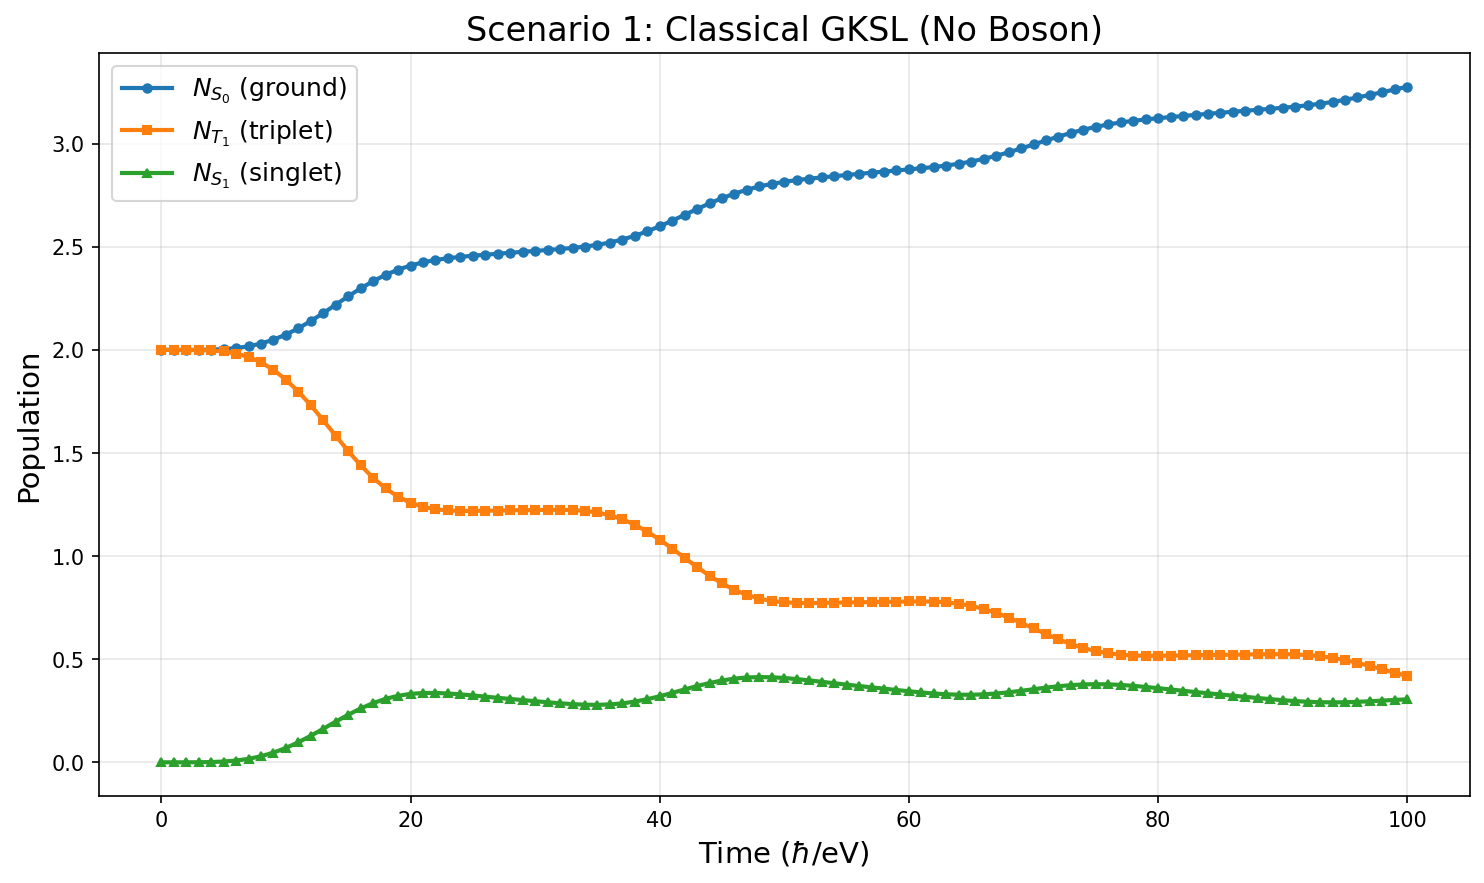

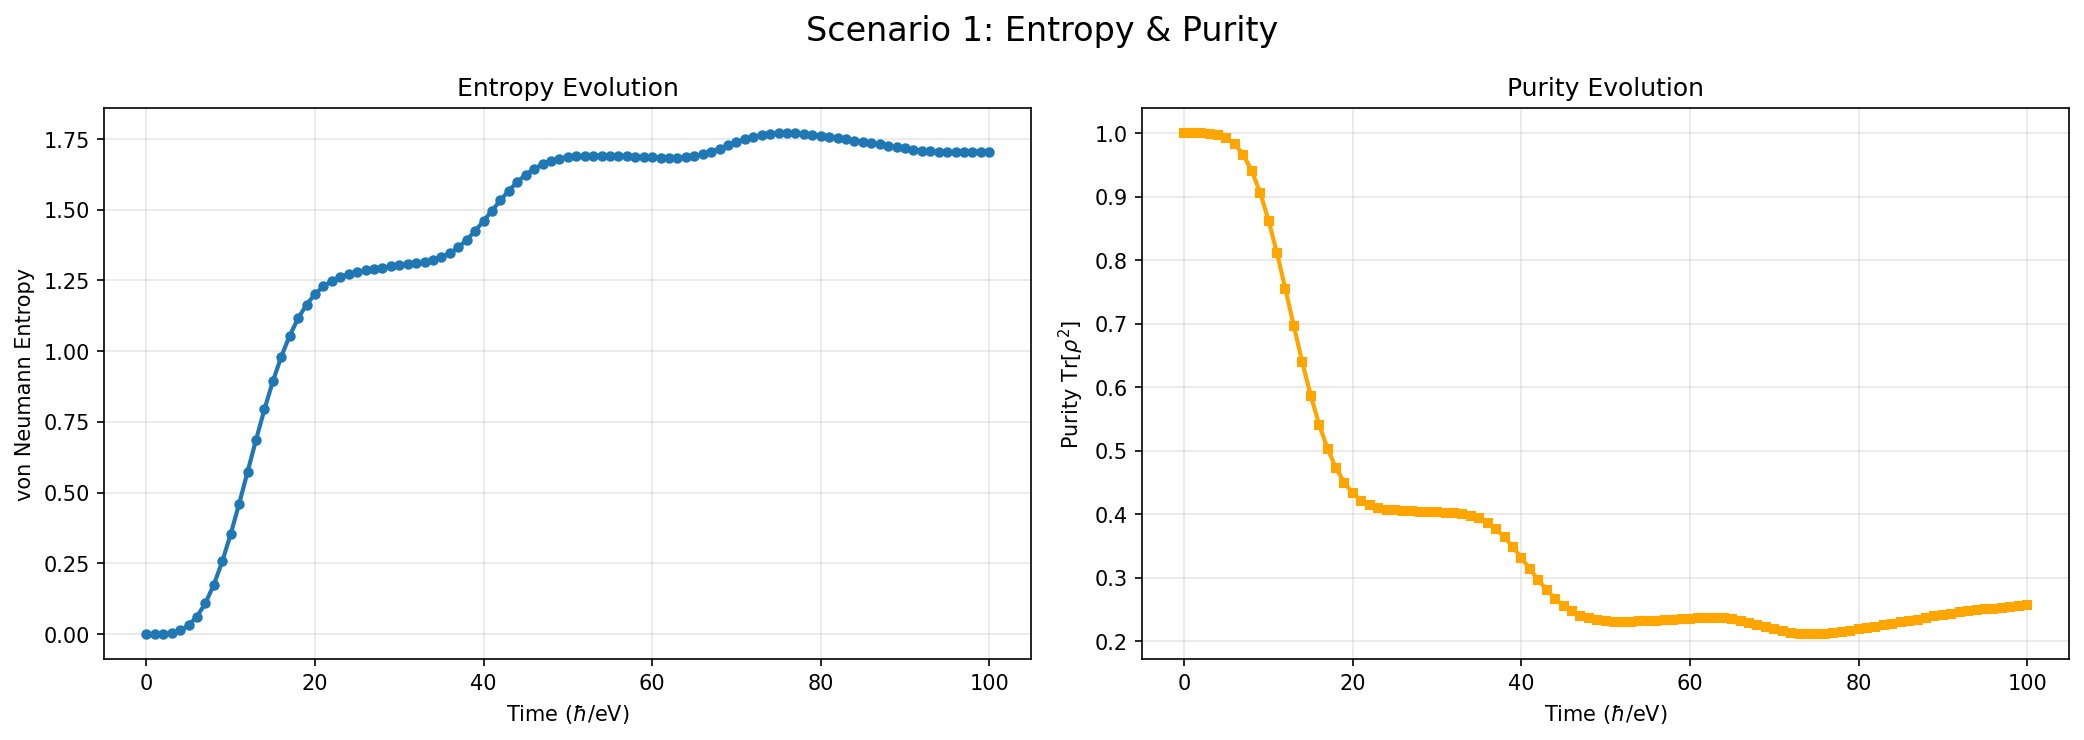

In [2]:
from classical_gksl_simulator import ClassicalGKSLSimulator
from gksl_visualization import plot_population_dynamics, plot_entropy_and_purity
from IPython.display import display, Image

os.makedirs("circuit_images", exist_ok=True)

sim1 = ClassicalGKSLSimulator(params)
result1 = sim1.simulate(t_max=t_max, n_steps=n_steps, initial_state='edge_triplet')

print(f'Elapsed time: {result1["elapsed_time"]:.2f}s')
print(f'Final populations: N_S0={result1["populations"][-1]["N_S0"]:.4f}, '
      f'N_T1={result1["populations"][-1]["N_T1"]:.4f}, '
      f'N_S1={result1["populations"][-1]["N_S1"]:.4f}')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result1["trace"]):.2e}')

plot_population_dynamics(result1, title='Scenario 1: Classical GKSL (No Boson)',
                         save_path='circuit_images/scenario1_population.png')
display(Image(filename='circuit_images/scenario1_population.png'))

plot_entropy_and_purity(result1, title='Scenario 1: Entropy & Purity',
                        save_path='circuit_images/scenario1_entropy_purity.png')
display(Image(filename='circuit_images/scenario1_entropy_purity.png'))


## 3. シナリオ5: Qudit GKSL（ボソン無し）

ネイティブqutrit(d=3) + Stinespring dilation + 2次対称Trotter分解。
4 qutrit + 26 ancilla qubit = 30量子ビット相当。
禁止状態なし（qutritの自然なエンコーディング）。

Elapsed time: 7.50s
System qutrits: 4
Ancilla qubits: 26
Estimated gates/step: 33
Total estimated gates: 3300
Trace conservation: max|Tr-1| = 8.44e-15


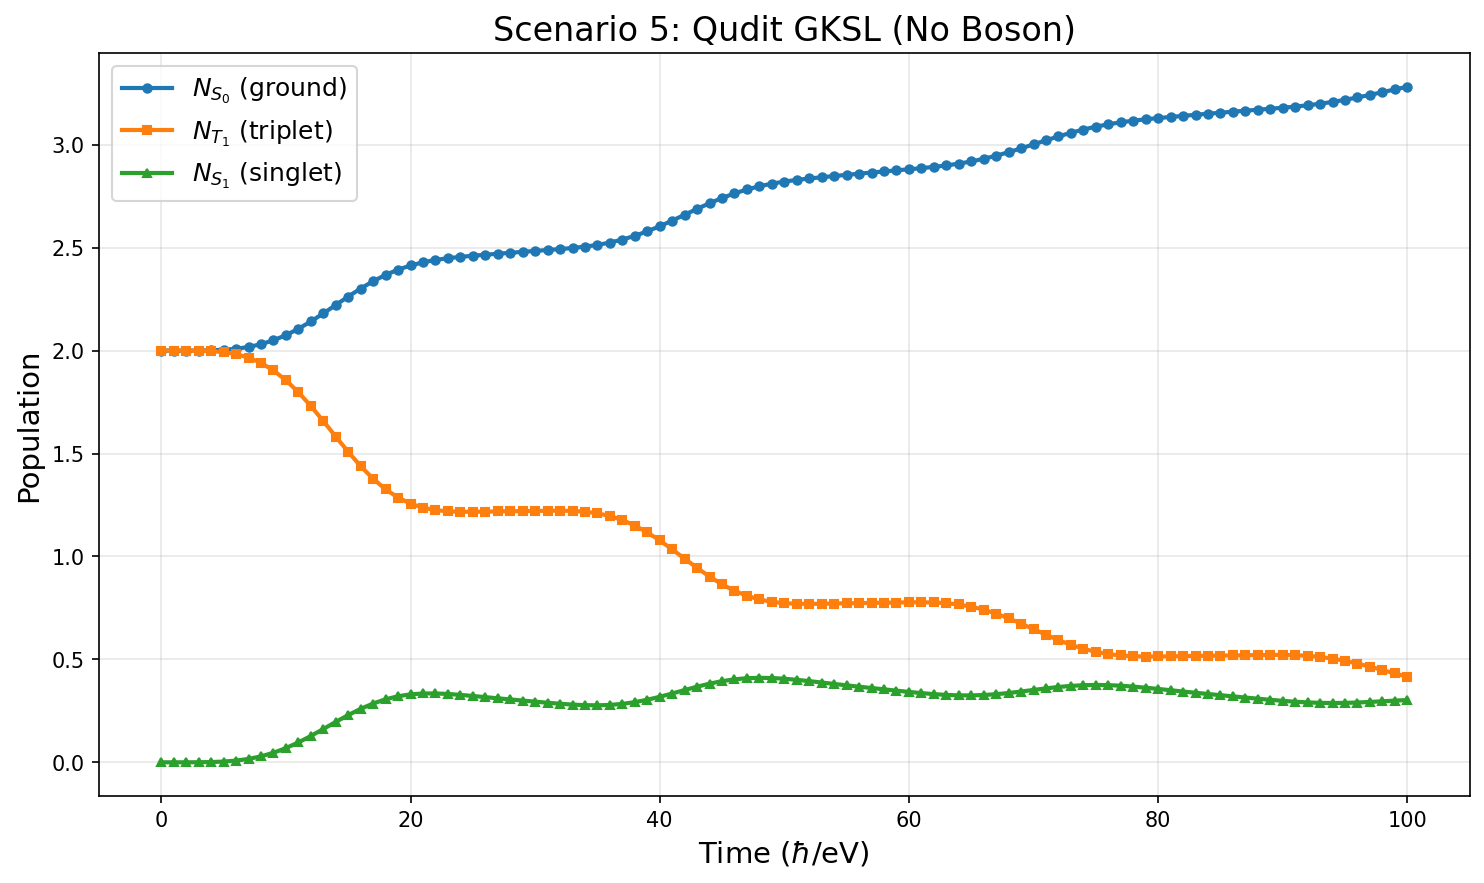

In [3]:
from qudit_gksl_simulator import QuditGKSLSimulator
from IPython.display import display, Image

sim5 = QuditGKSLSimulator(params)
result5 = sim5.simulate(t_max=t_max, n_steps=n_steps_quantum, initial_state='edge_triplet')

print(f'Elapsed time: {result5["elapsed_time"]:.2f}s')
print(f'System qutrits: {result5["n_system_qudits"]}')
print(f'Ancilla qubits: {result5["n_ancilla_qubits"]}')
print(f'Estimated gates/step: {result5["estimated_gates_per_step"]}')
print(f'Total estimated gates: {result5["total_estimated_gates"]}')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result5["trace"]):.2e}')

plot_population_dynamics(result5, title='Scenario 5: Qudit GKSL (No Boson)',
                         save_path='circuit_images/scenario5_population.png')
display(Image(filename='circuit_images/scenario5_population.png'))


## 4. シナリオ3: Qubit GKSL（ボソン無し）

2-qubitエンコーディング(|00⟩=S0, |01⟩=T1, |10⟩=S1, |11⟩=禁止) + Stinespring + Trotter。
8 system qubit + 26 ancilla = 34 qubit。

Elapsed time: 20.10s
System qubits: 8
Ancilla qubits: 26
Total qubits: 34
Trace conservation: max|Tr-1| = 8.22e-15


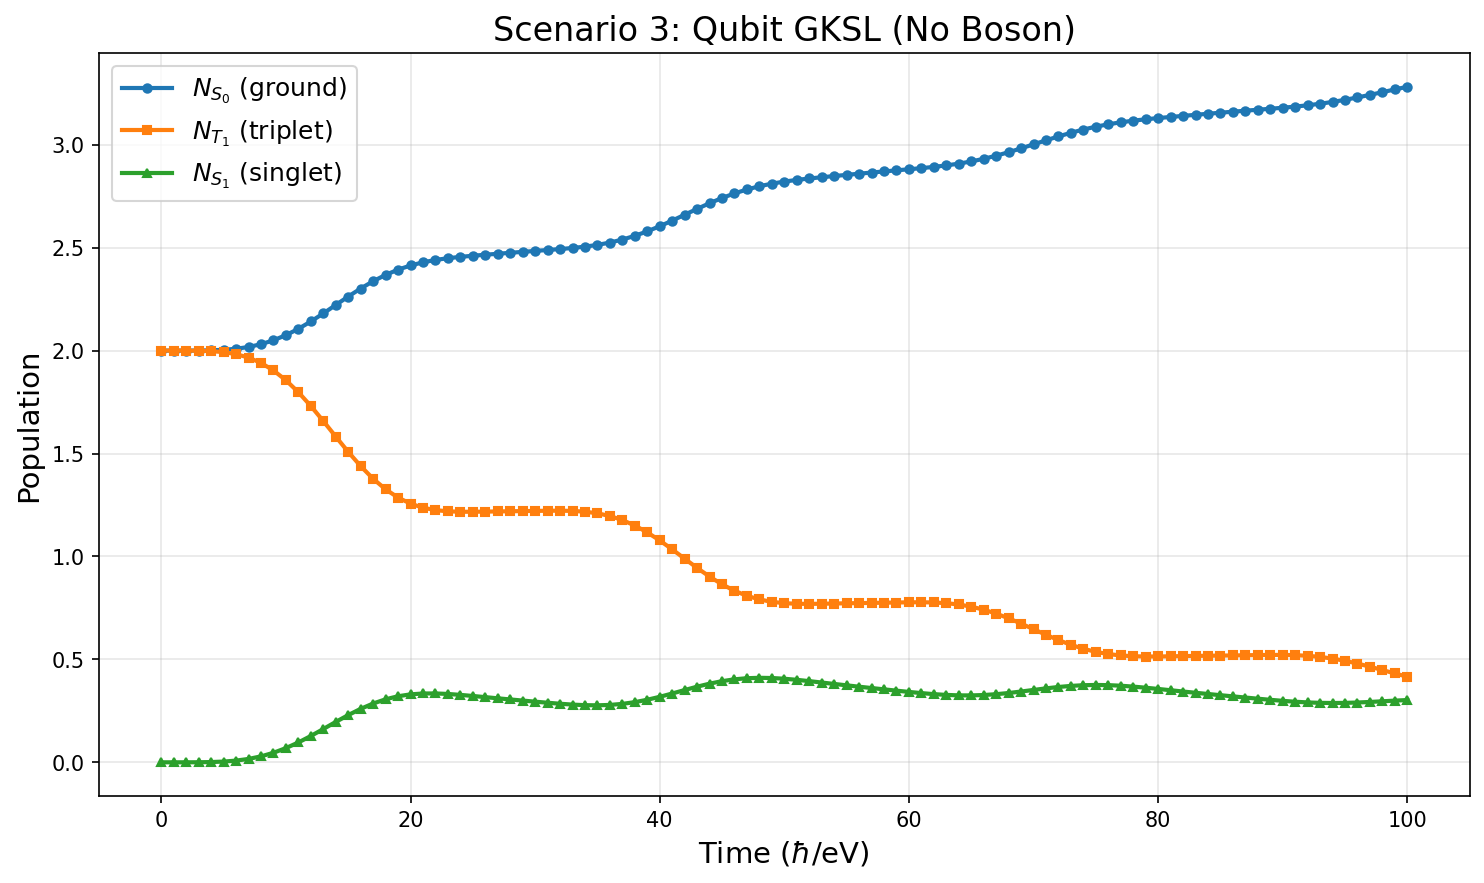

In [4]:
from qubit_gksl_simulator import QubitGKSLSimulator
from IPython.display import display, Image

sim3 = QubitGKSLSimulator(params)
result3 = sim3.simulate(t_max=t_max, n_steps=n_steps_quantum, initial_state='edge_triplet')

print(f'Elapsed time: {result3["elapsed_time"]:.2f}s')
print(f'System qubits: {result3["n_sys_qubits"]}')
print(f'Ancilla qubits: {result3["n_ancilla"]}')
print(f'Total qubits: {result3["n_total_qubits"]}')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result3["trace"]):.2e}')

plot_population_dynamics(result3, title='Scenario 3: Qubit GKSL (No Boson)',
                         save_path='circuit_images/scenario3_population.png')
display(Image(filename='circuit_images/scenario3_population.png'))


## 5. シナリオ2: 古典GKSL（ボソン有り）

Holstein型電子-フォノン結合を含むBDF法ODE積分。
計算負荷のため、2分子・n_max=1で実行（dim=36）。

Elapsed time: 0.27s
Trace conservation: max|Tr-1| = 5.77e-15


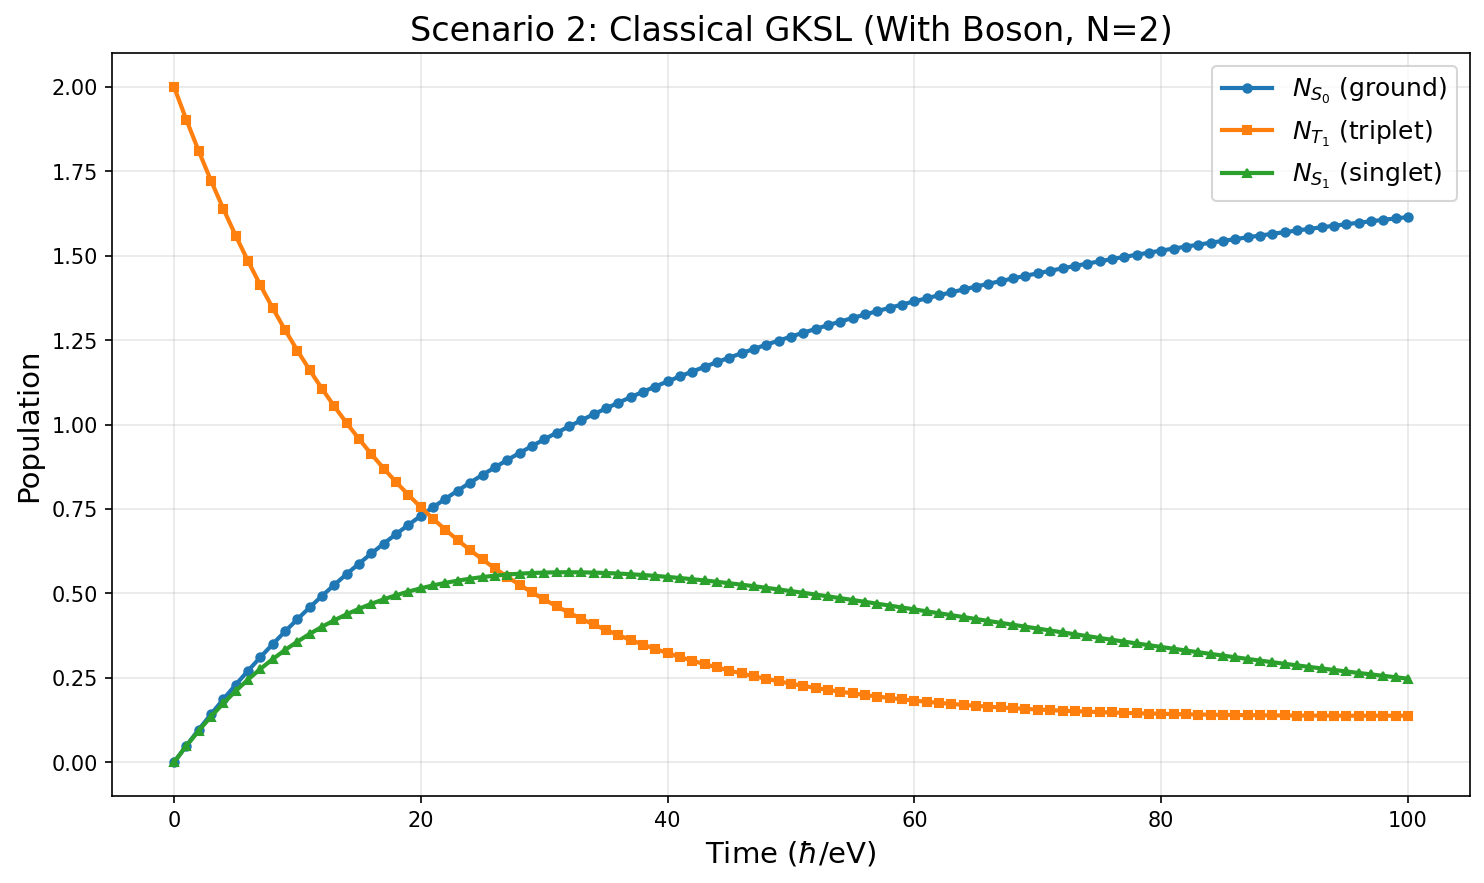

In [5]:
from classical_gksl_boson_simulator import ClassicalGKSLBosonSimulator
from IPython.display import display, Image

sim2 = ClassicalGKSLBosonSimulator(params_boson)
result2 = sim2.simulate(t_max=t_max, n_steps=n_steps, initial_state='edge_triplet')

print(f'Elapsed time: {result2["elapsed_time"]:.2f}s')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result2["trace"]):.2e}')

plot_population_dynamics(result2, title='Scenario 2: Classical GKSL (With Boson, N=2)',
                         save_path='circuit_images/scenario2_population.png')
display(Image(filename='circuit_images/scenario2_population.png'))


## 6. シナリオ6: Qudit GKSL（ボソン有り）

qutrit電子系 + qutritフォノン系 + Stinespring dilation。
2分子・n_max=1で実行。

Elapsed time: 0.58s
Trace conservation: max|Tr-1| = 1.33e-14


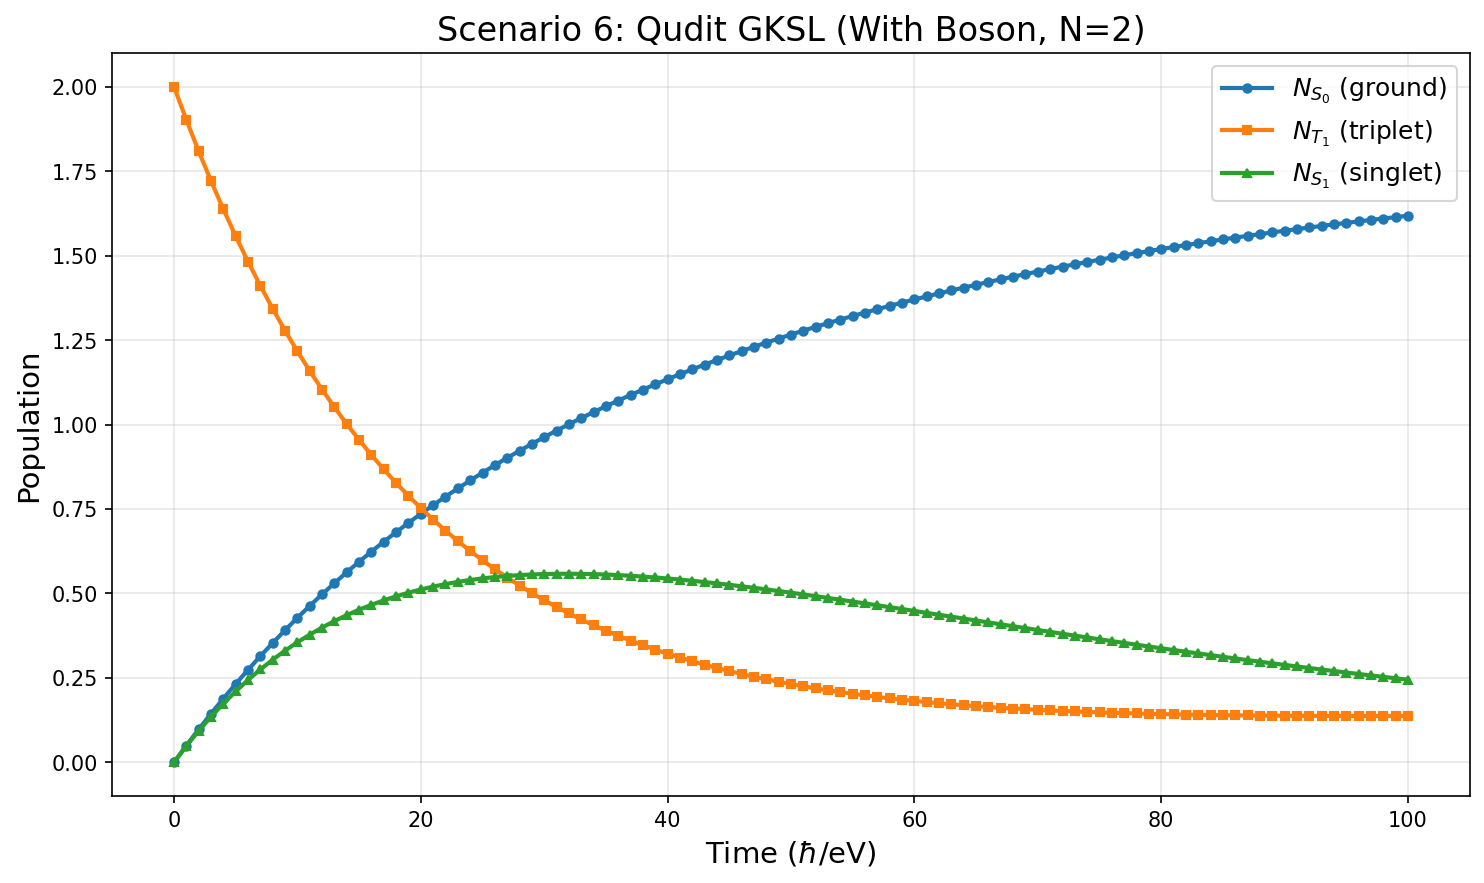

In [6]:
from qudit_gksl_boson_simulator import QuditGKSLBosonSimulator
from IPython.display import display, Image

sim6 = QuditGKSLBosonSimulator(params_boson)
result6 = sim6.simulate(t_max=t_max, n_steps=n_steps_quantum, initial_state='edge_triplet')

print(f'Elapsed time: {result6["elapsed_time"]:.2f}s')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result6["trace"]):.2e}')

plot_population_dynamics(result6, title='Scenario 6: Qudit GKSL (With Boson, N=2)',
                         save_path='circuit_images/scenario6_population.png')
display(Image(filename='circuit_images/scenario6_population.png'))


## 7. シナリオ4: Qubit GKSL（ボソン有り）

Qubit Stinespring + Trotter in 拡張空間。
2分子・n_max=1で実行。

Elapsed time: 2.52s
Trace conservation: max|Tr-1| = 1.33e-14


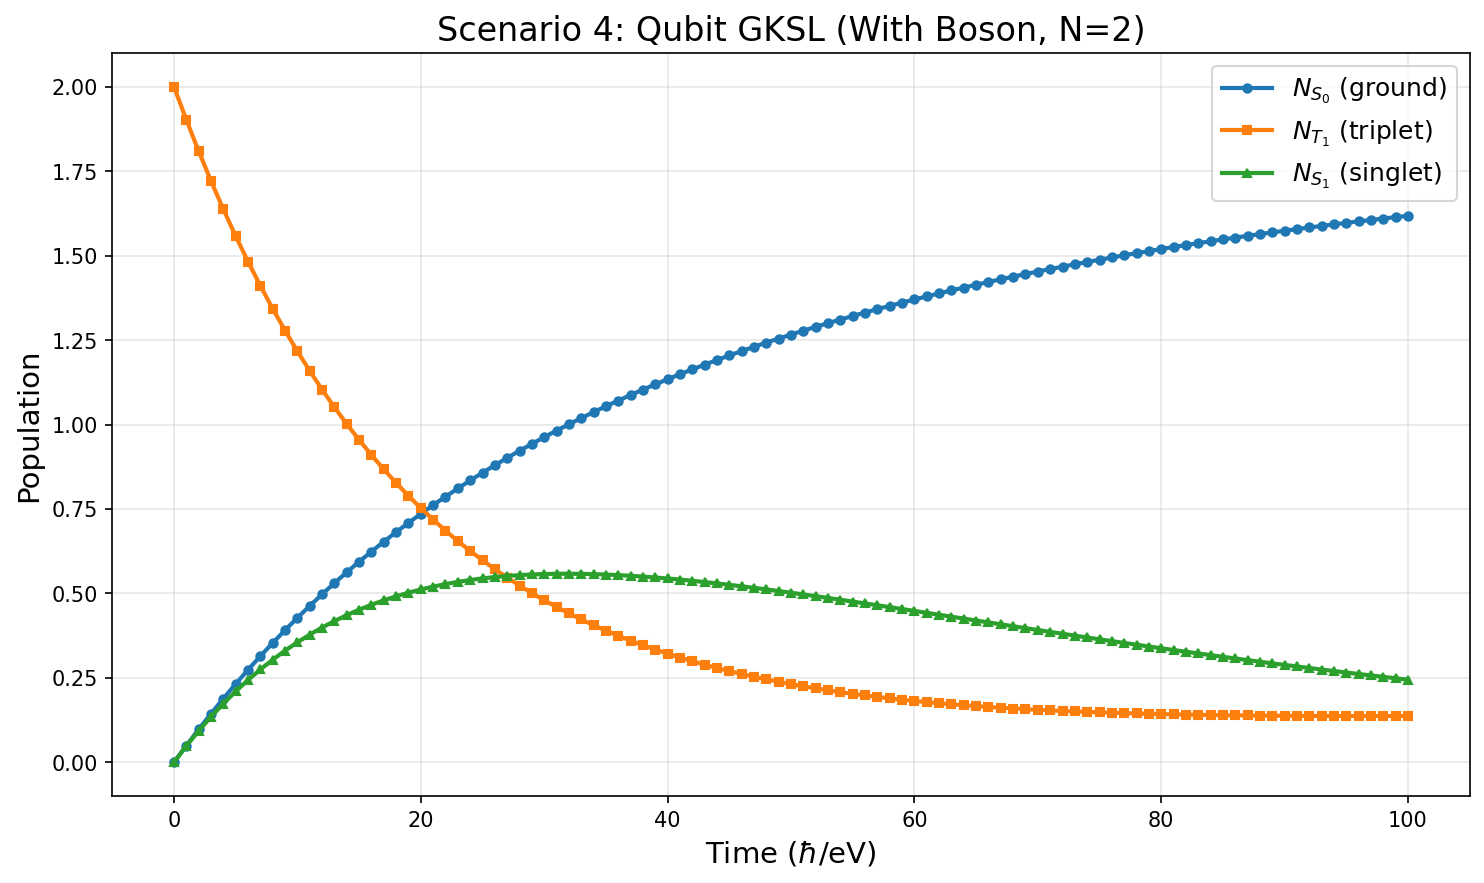

In [7]:
from qubit_gksl_boson_simulator import QubitGKSLBosonSimulator
from IPython.display import display, Image

sim4 = QubitGKSLBosonSimulator(params_boson)
result4 = sim4.simulate(t_max=t_max, n_steps=n_steps_quantum, initial_state='edge_triplet')

print(f'Elapsed time: {result4["elapsed_time"]:.2f}s')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result4["trace"]):.2e}')

plot_population_dynamics(result4, title='Scenario 4: Qubit GKSL (With Boson, N=2)',
                         save_path='circuit_images/scenario4_population.png')
display(Image(filename='circuit_images/scenario4_population.png'))


## 追補: 1トロッターステップ量子回路の可視化

各量子シミュレーションで1トロッターステップに実際に適用している回路（または等価な行列演算ゲート列）を全て表示します。


Scenario 3: Qubit GKSL (No Boson) - 1 Trotter Step
subcircuits: 28

[01] hamiltonian_half_1 -> circuit_images/scenario3_qubit_nb_01_hamiltonian_half_1.png


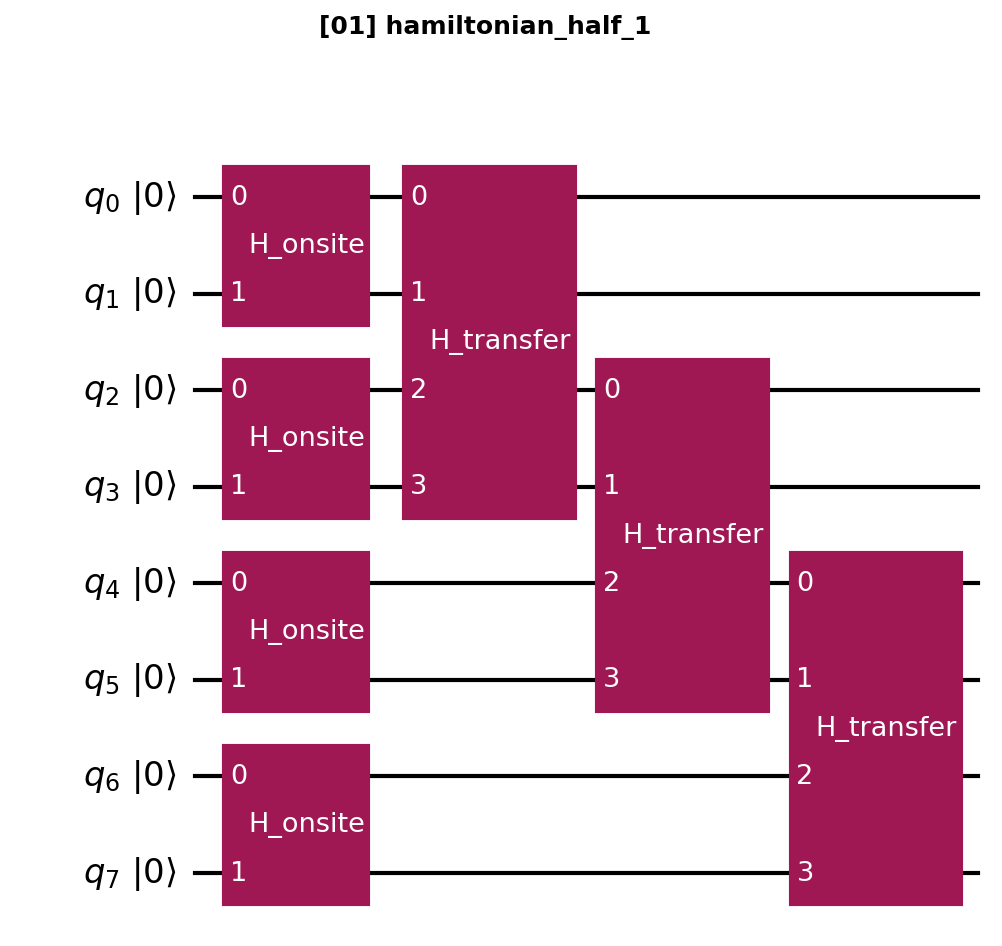


[02] stinespring_pair_0 -> circuit_images/scenario3_qubit_nb_02_stinespring_pair_0.png


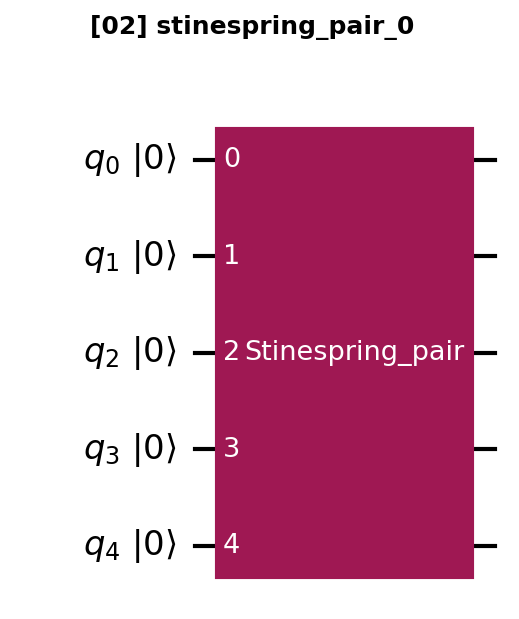


[03] stinespring_pair_1 -> circuit_images/scenario3_qubit_nb_03_stinespring_pair_1.png


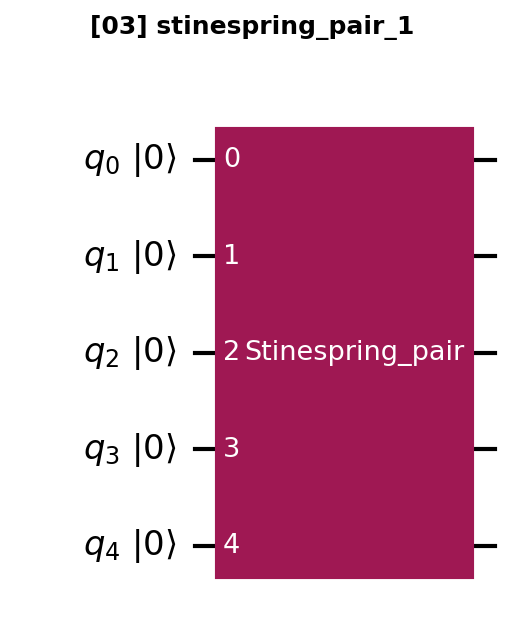


[04] stinespring_pair_2 -> circuit_images/scenario3_qubit_nb_04_stinespring_pair_2.png


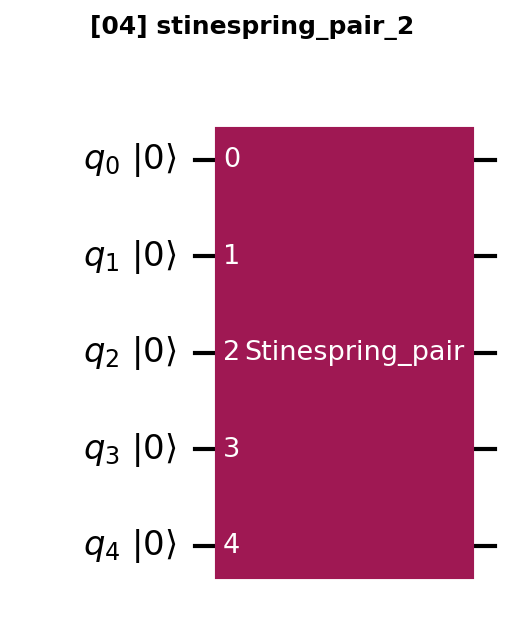


[05] stinespring_pair_3 -> circuit_images/scenario3_qubit_nb_05_stinespring_pair_3.png


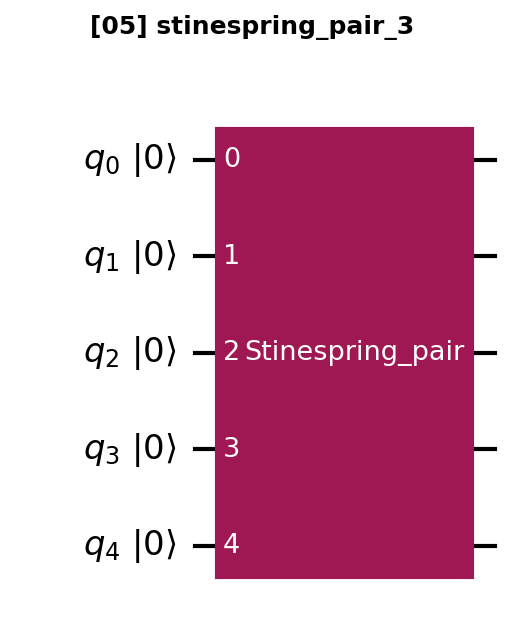


[06] stinespring_pair_4 -> circuit_images/scenario3_qubit_nb_06_stinespring_pair_4.png


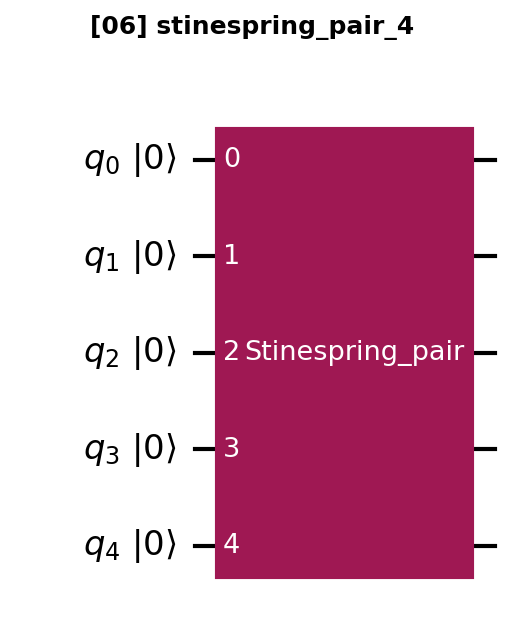


[07] stinespring_pair_5 -> circuit_images/scenario3_qubit_nb_07_stinespring_pair_5.png


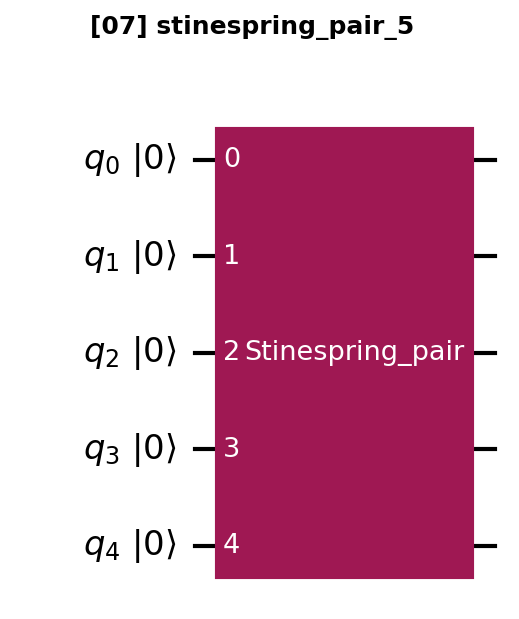


[08] stinespring_single_6 -> circuit_images/scenario3_qubit_nb_08_stinespring_single_6.png


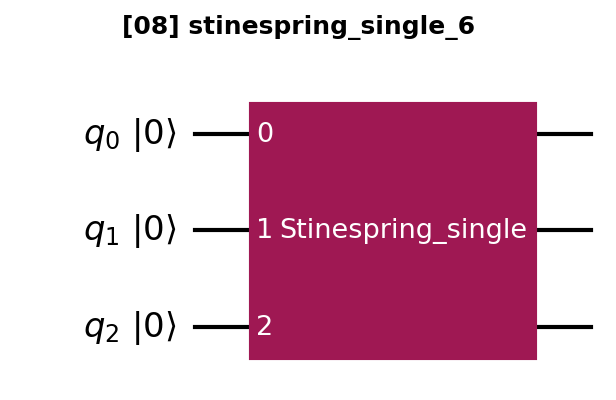


[09] stinespring_single_7 -> circuit_images/scenario3_qubit_nb_09_stinespring_single_7.png


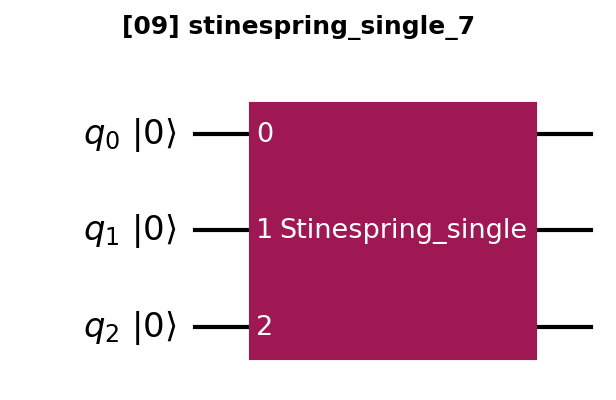


[10] stinespring_single_8 -> circuit_images/scenario3_qubit_nb_10_stinespring_single_8.png


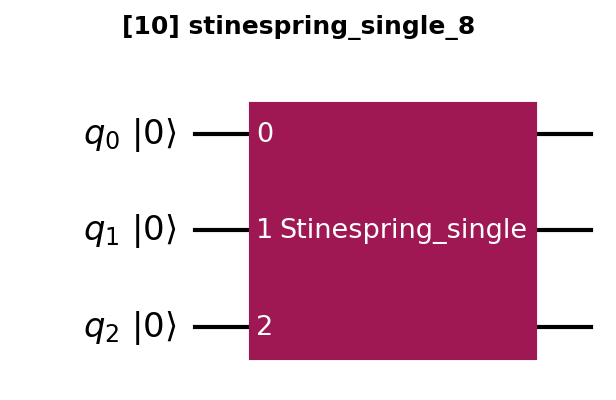


[11] stinespring_single_9 -> circuit_images/scenario3_qubit_nb_11_stinespring_single_9.png


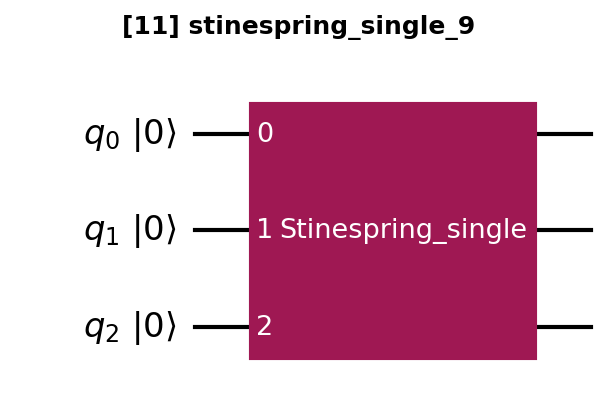


[12] stinespring_single_10 -> circuit_images/scenario3_qubit_nb_12_stinespring_single_10.png


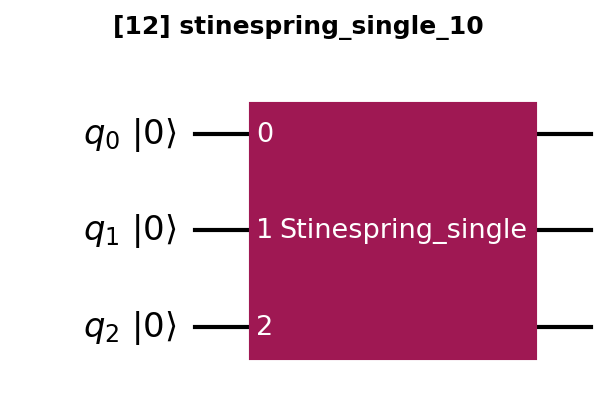


[13] stinespring_single_11 -> circuit_images/scenario3_qubit_nb_13_stinespring_single_11.png


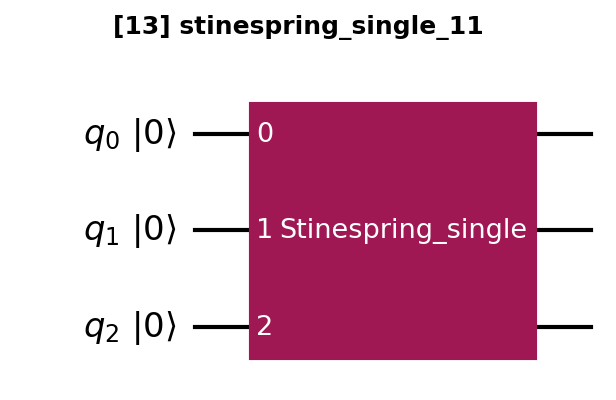


[14] stinespring_single_12 -> circuit_images/scenario3_qubit_nb_14_stinespring_single_12.png


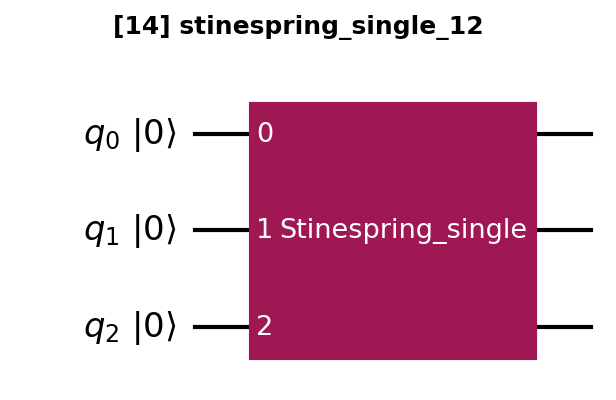


[15] stinespring_single_13 -> circuit_images/scenario3_qubit_nb_15_stinespring_single_13.png


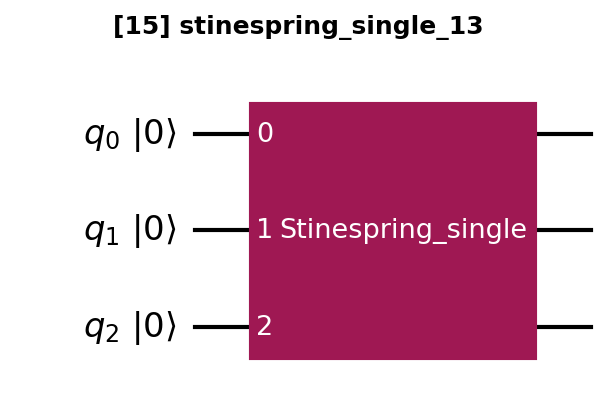


[16] stinespring_single_14 -> circuit_images/scenario3_qubit_nb_16_stinespring_single_14.png


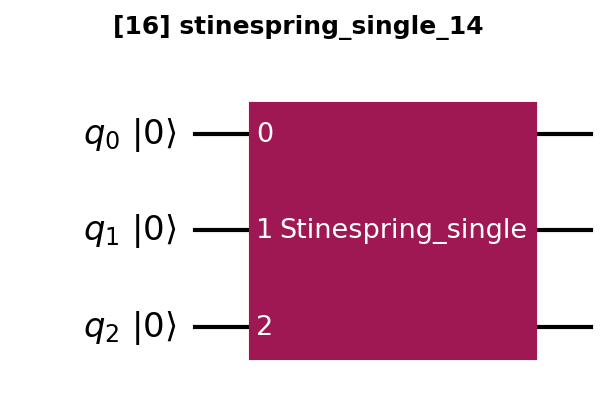


[17] stinespring_single_15 -> circuit_images/scenario3_qubit_nb_17_stinespring_single_15.png


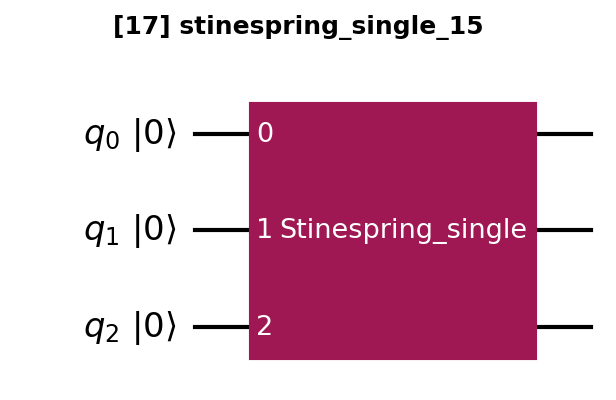


[18] stinespring_single_16 -> circuit_images/scenario3_qubit_nb_18_stinespring_single_16.png


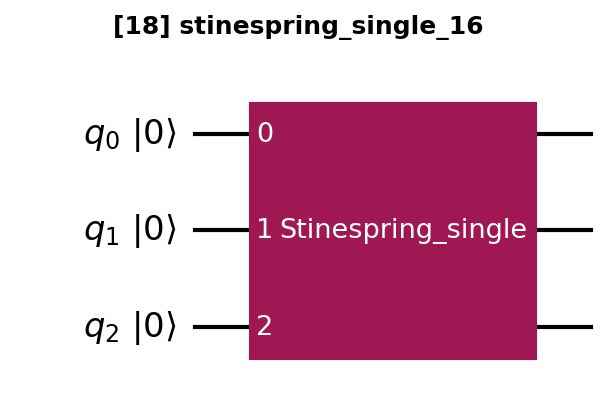


[19] stinespring_single_17 -> circuit_images/scenario3_qubit_nb_19_stinespring_single_17.png


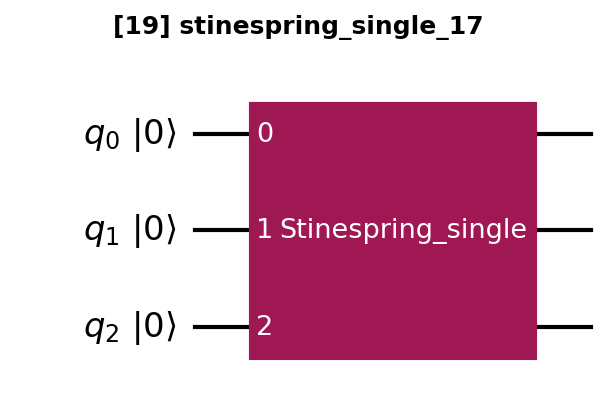


[20] stinespring_single_18 -> circuit_images/scenario3_qubit_nb_20_stinespring_single_18.png


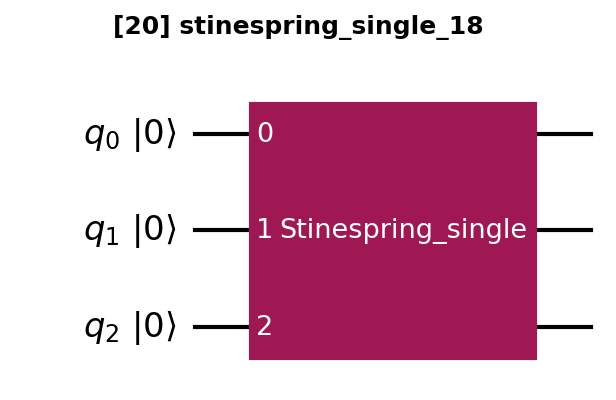


[21] stinespring_single_19 -> circuit_images/scenario3_qubit_nb_21_stinespring_single_19.png


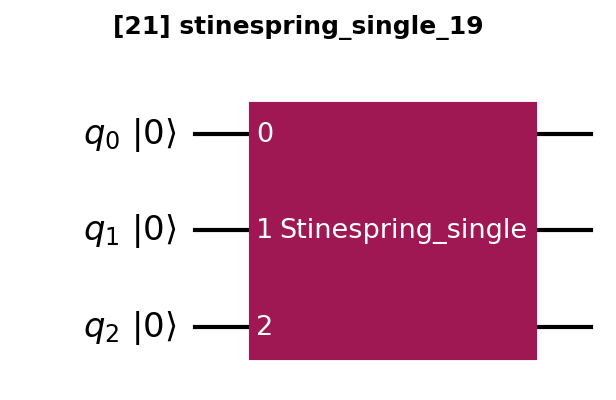


[22] stinespring_single_20 -> circuit_images/scenario3_qubit_nb_22_stinespring_single_20.png


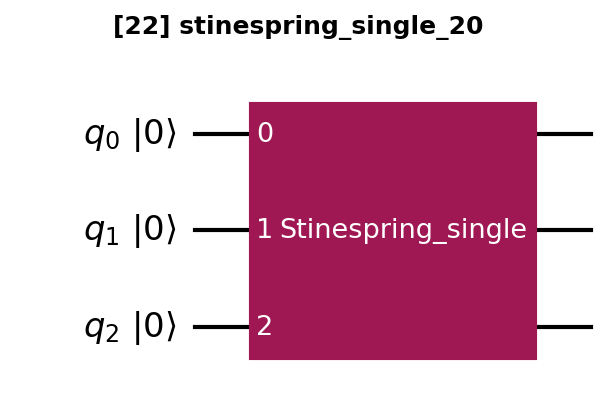


[23] stinespring_single_21 -> circuit_images/scenario3_qubit_nb_23_stinespring_single_21.png


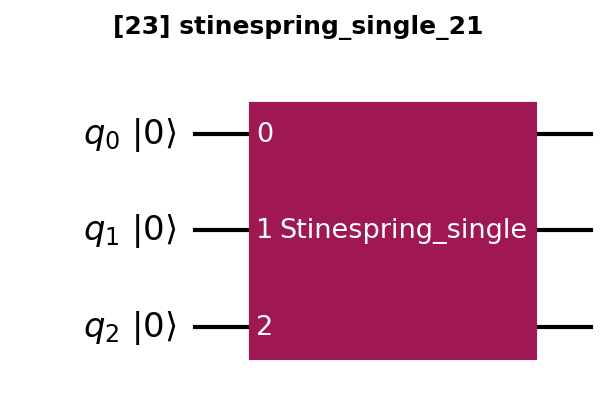


[24] stinespring_single_22 -> circuit_images/scenario3_qubit_nb_24_stinespring_single_22.png


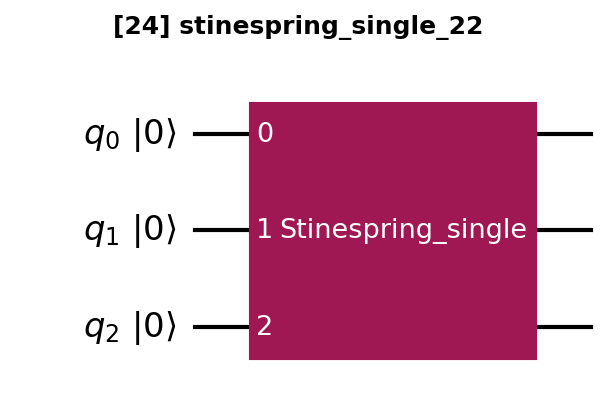


[25] stinespring_single_23 -> circuit_images/scenario3_qubit_nb_25_stinespring_single_23.png


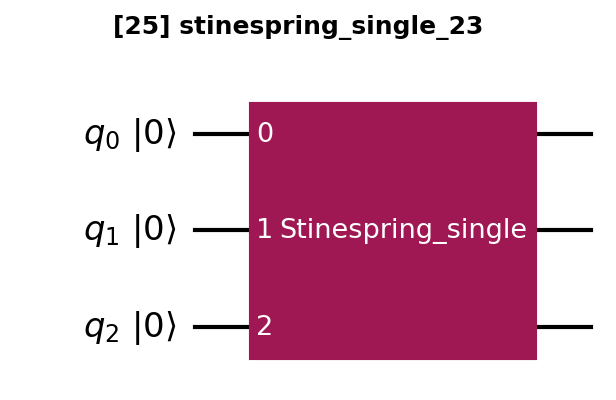


[26] stinespring_single_24 -> circuit_images/scenario3_qubit_nb_26_stinespring_single_24.png


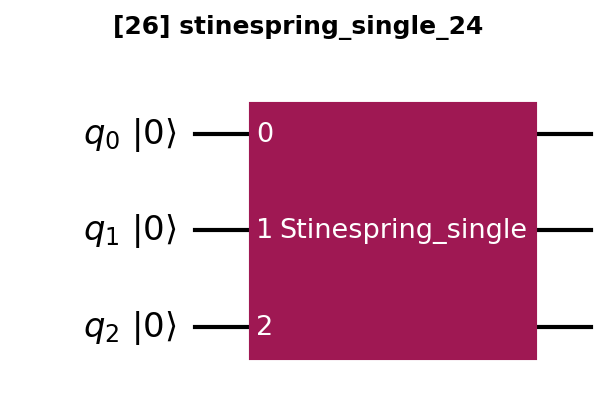


[27] stinespring_single_25 -> circuit_images/scenario3_qubit_nb_27_stinespring_single_25.png


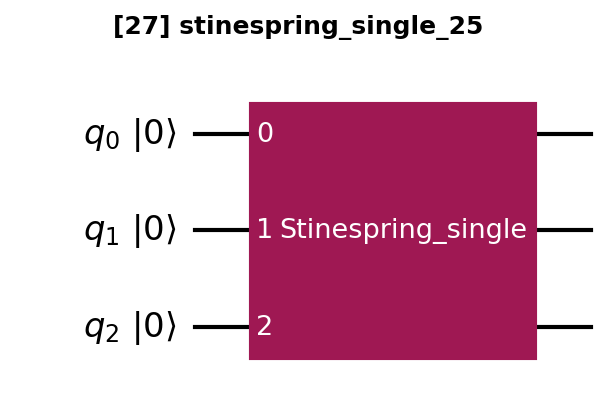


[28] hamiltonian_half_2 -> circuit_images/scenario3_qubit_nb_28_hamiltonian_half_2.png


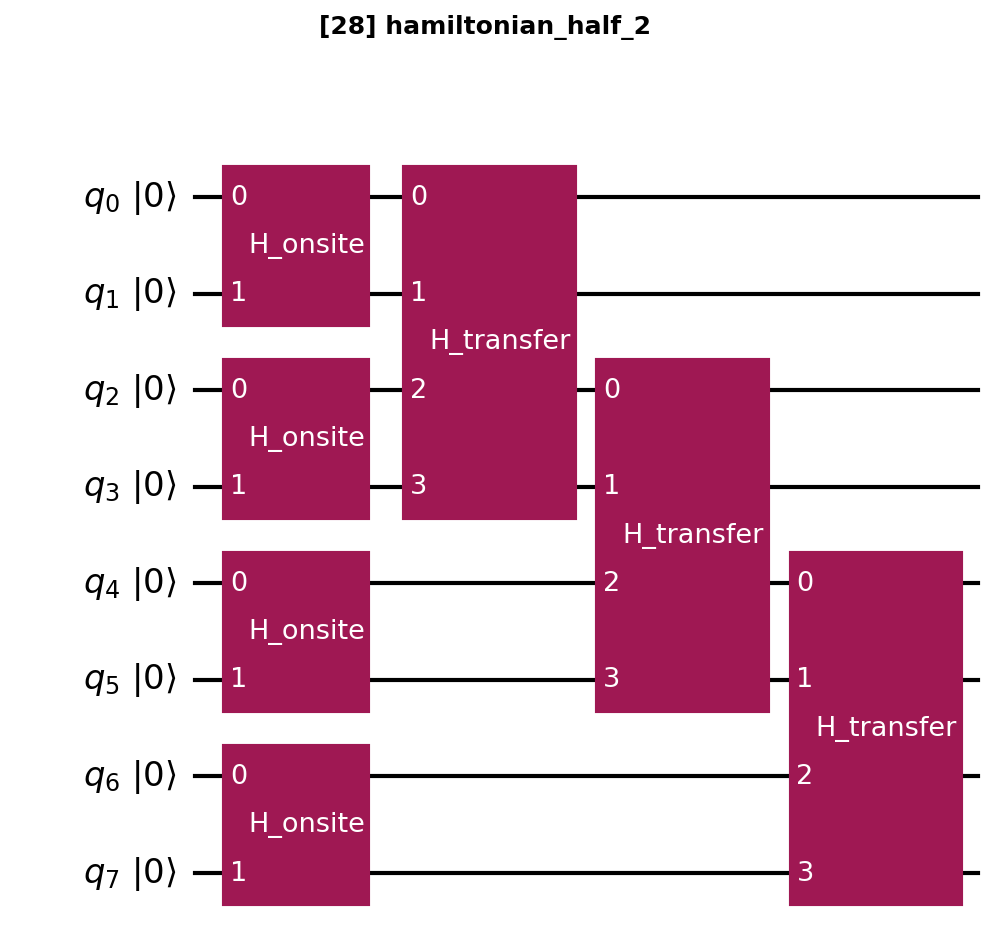


Scenario 5: Qudit GKSL (No Boson) - 1 Trotter Step
subcircuits: 28

[01] hamiltonian_half_1 -> circuit_images/scenario5_qudit_nb_01_hamiltonian_half_1.png


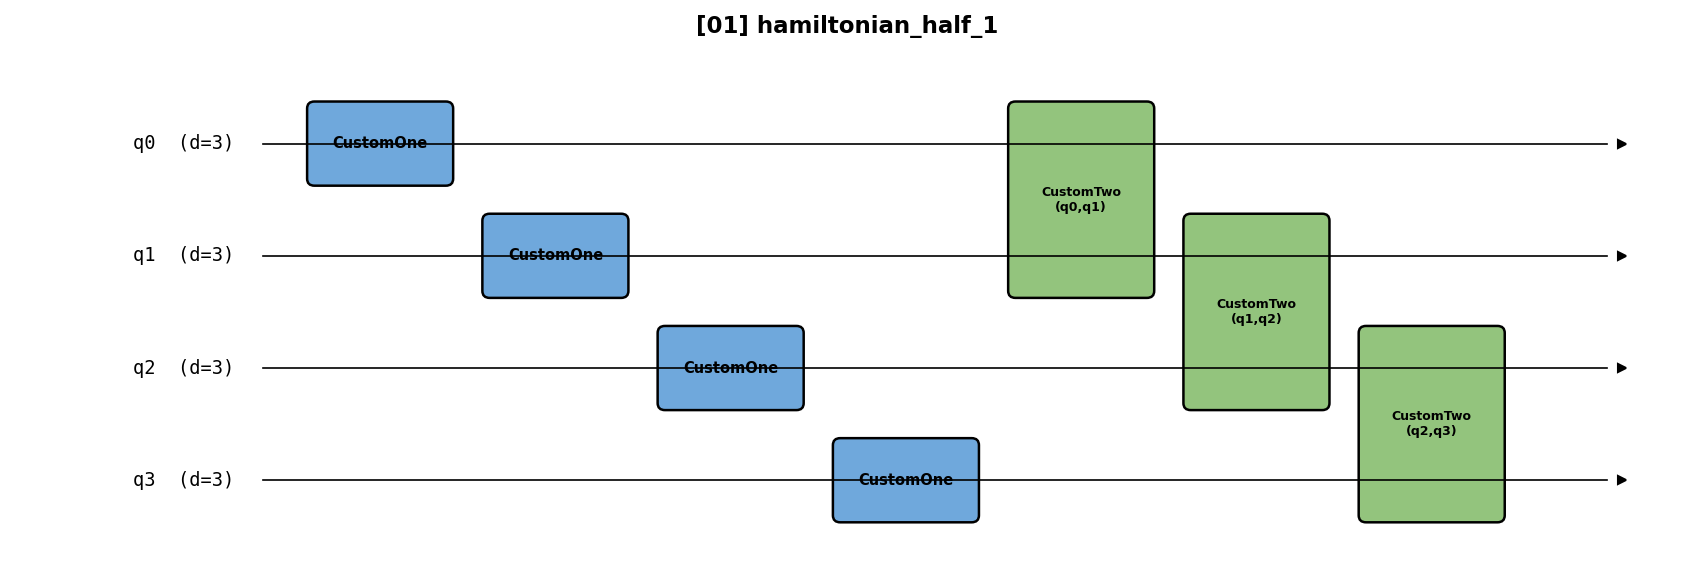


[02] stinespring_pair_0 -> circuit_images/scenario5_qudit_nb_02_stinespring_pair_0.png


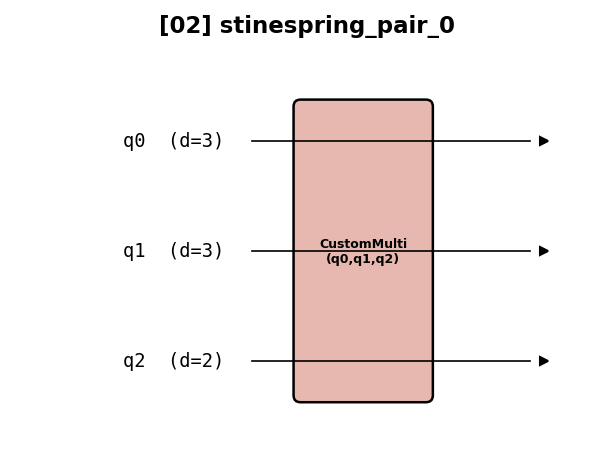


[03] stinespring_pair_1 -> circuit_images/scenario5_qudit_nb_03_stinespring_pair_1.png


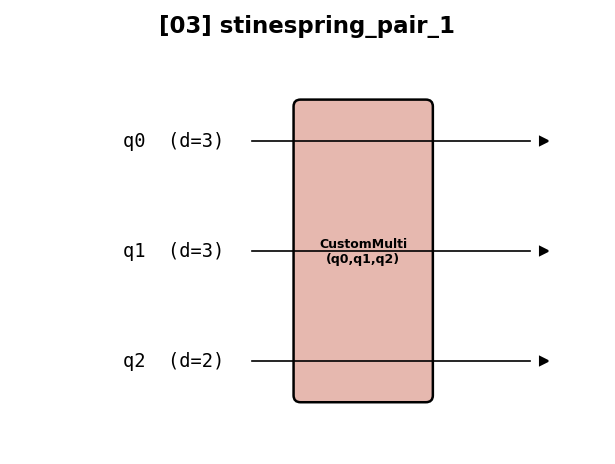


[04] stinespring_pair_2 -> circuit_images/scenario5_qudit_nb_04_stinespring_pair_2.png


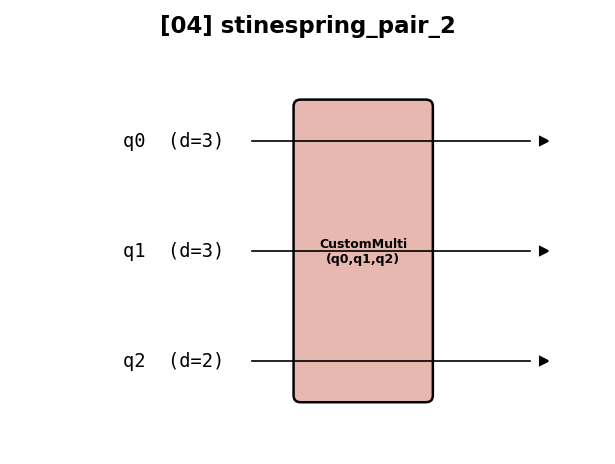


[05] stinespring_pair_3 -> circuit_images/scenario5_qudit_nb_05_stinespring_pair_3.png


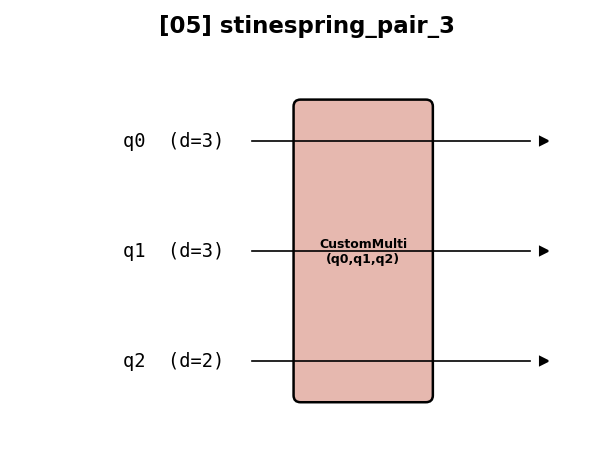


[06] stinespring_pair_4 -> circuit_images/scenario5_qudit_nb_06_stinespring_pair_4.png


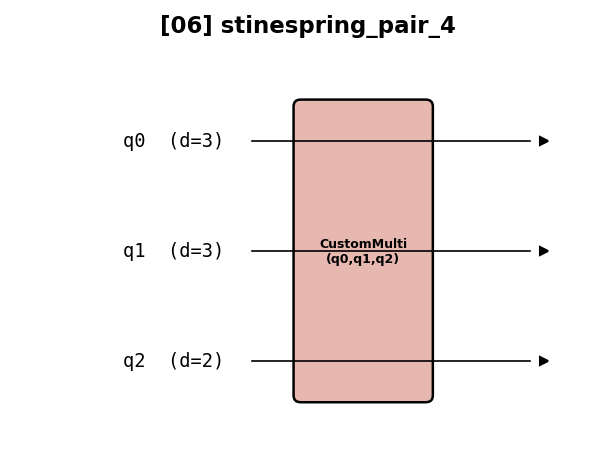


[07] stinespring_pair_5 -> circuit_images/scenario5_qudit_nb_07_stinespring_pair_5.png


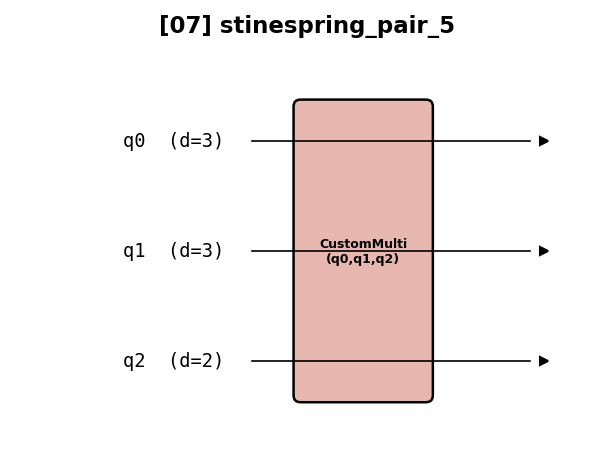


[08] stinespring_single_6 -> circuit_images/scenario5_qudit_nb_08_stinespring_single_6.png


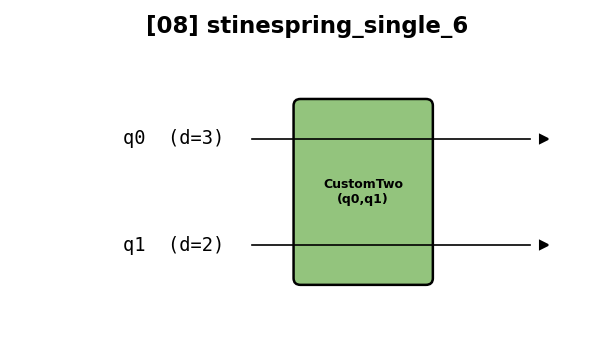


[09] stinespring_single_7 -> circuit_images/scenario5_qudit_nb_09_stinespring_single_7.png


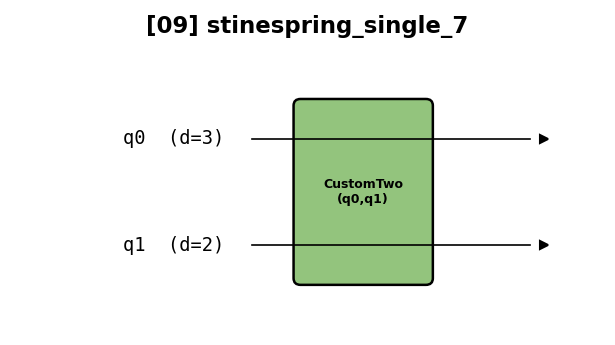


[10] stinespring_single_8 -> circuit_images/scenario5_qudit_nb_10_stinespring_single_8.png


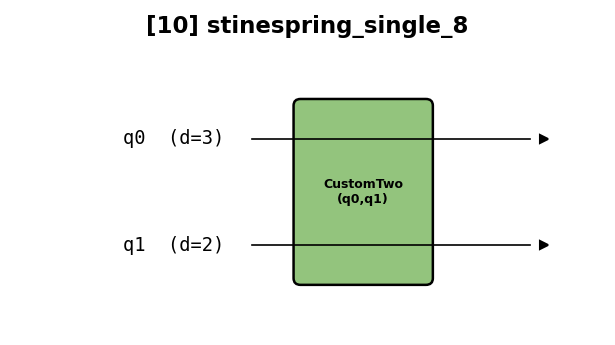


[11] stinespring_single_9 -> circuit_images/scenario5_qudit_nb_11_stinespring_single_9.png


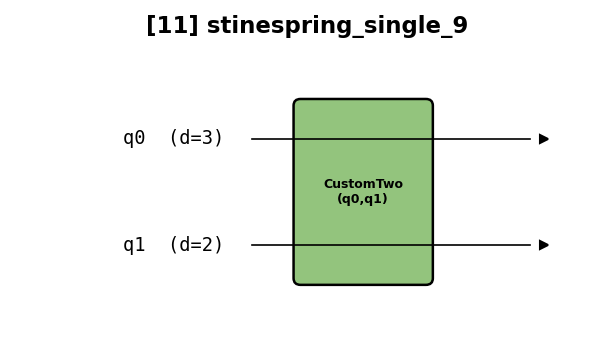


[12] stinespring_single_10 -> circuit_images/scenario5_qudit_nb_12_stinespring_single_10.png


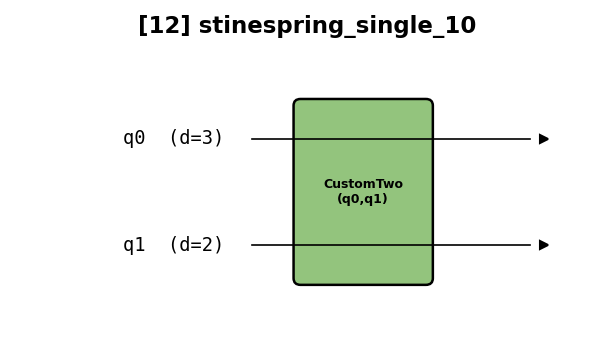


[13] stinespring_single_11 -> circuit_images/scenario5_qudit_nb_13_stinespring_single_11.png


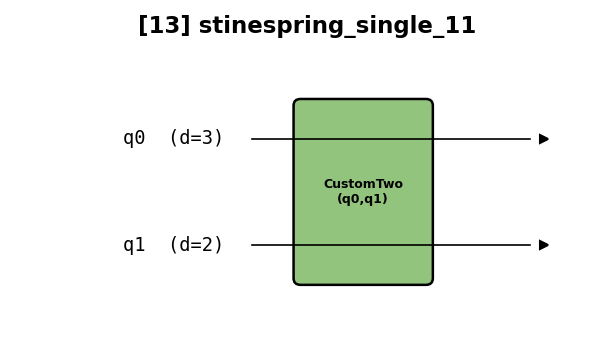


[14] stinespring_single_12 -> circuit_images/scenario5_qudit_nb_14_stinespring_single_12.png


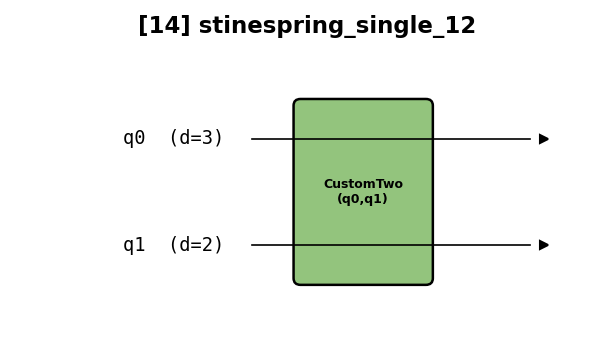


[15] stinespring_single_13 -> circuit_images/scenario5_qudit_nb_15_stinespring_single_13.png


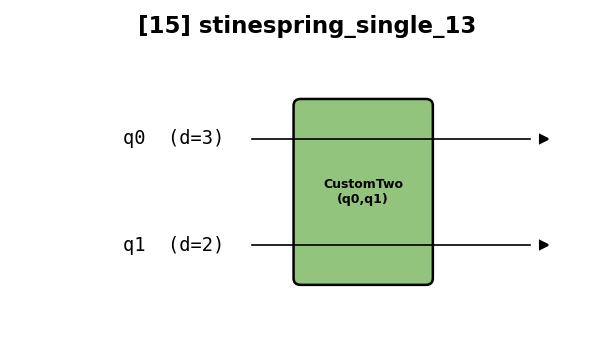


[16] stinespring_single_14 -> circuit_images/scenario5_qudit_nb_16_stinespring_single_14.png


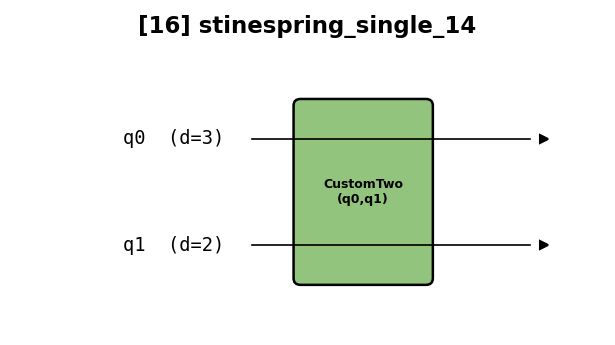


[17] stinespring_single_15 -> circuit_images/scenario5_qudit_nb_17_stinespring_single_15.png


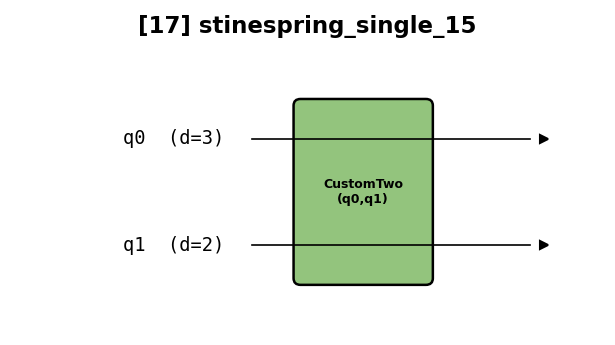


[18] stinespring_single_16 -> circuit_images/scenario5_qudit_nb_18_stinespring_single_16.png


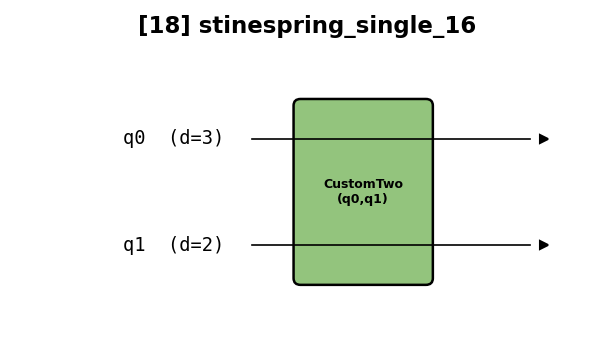


[19] stinespring_single_17 -> circuit_images/scenario5_qudit_nb_19_stinespring_single_17.png


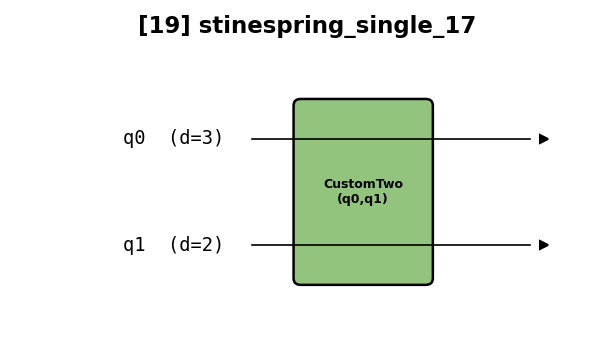


[20] stinespring_single_18 -> circuit_images/scenario5_qudit_nb_20_stinespring_single_18.png


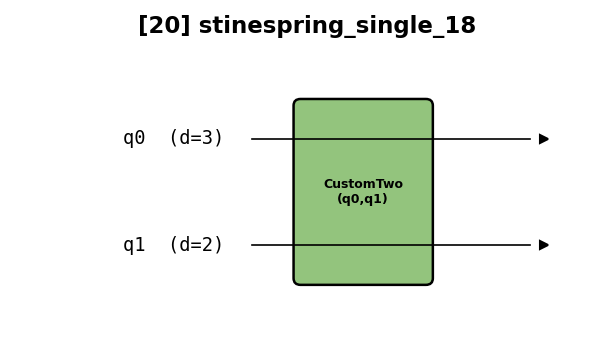


[21] stinespring_single_19 -> circuit_images/scenario5_qudit_nb_21_stinespring_single_19.png


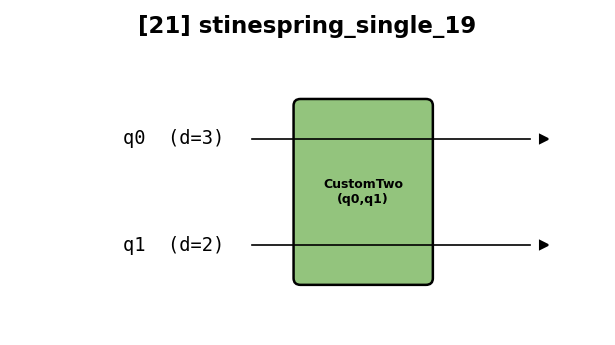


[22] stinespring_single_20 -> circuit_images/scenario5_qudit_nb_22_stinespring_single_20.png


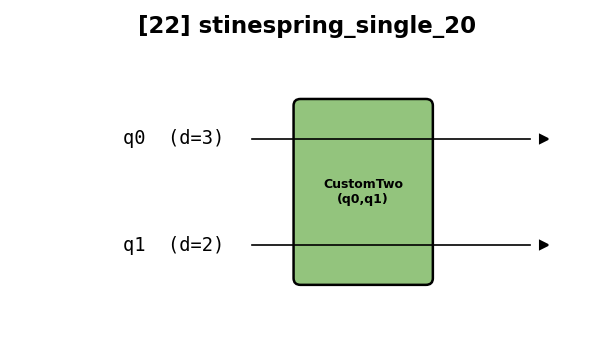


[23] stinespring_single_21 -> circuit_images/scenario5_qudit_nb_23_stinespring_single_21.png


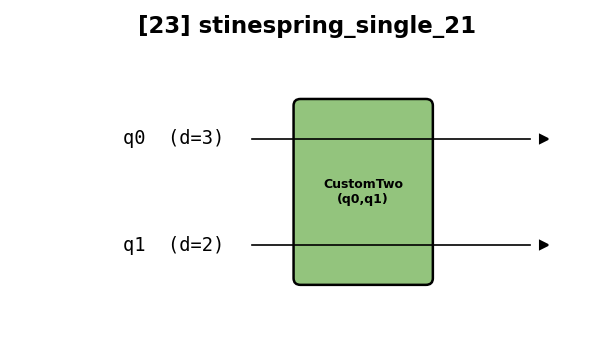


[24] stinespring_single_22 -> circuit_images/scenario5_qudit_nb_24_stinespring_single_22.png


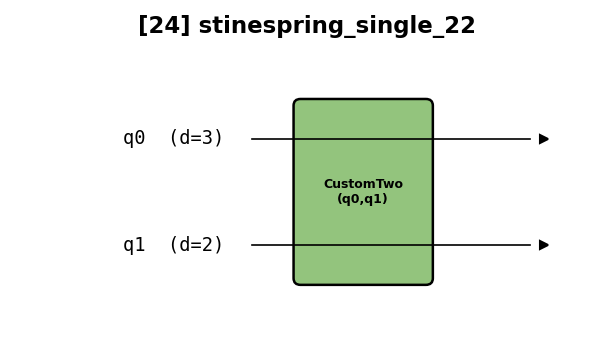


[25] stinespring_single_23 -> circuit_images/scenario5_qudit_nb_25_stinespring_single_23.png


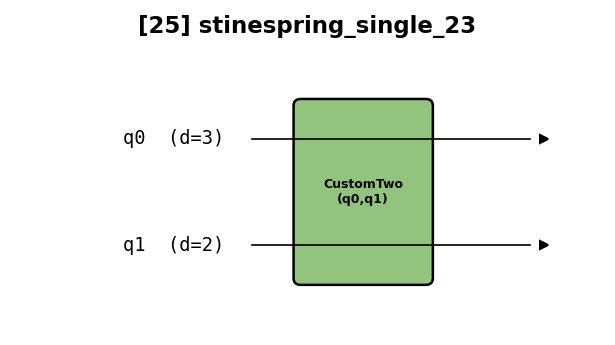


[26] stinespring_single_24 -> circuit_images/scenario5_qudit_nb_26_stinespring_single_24.png


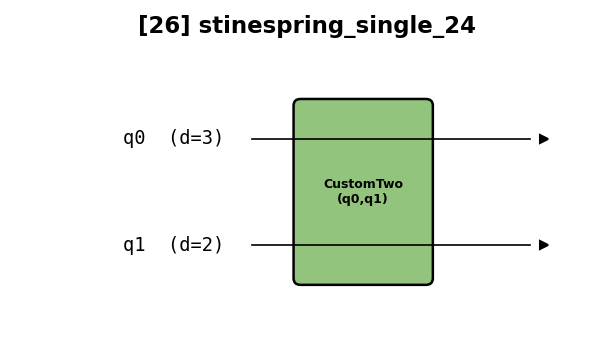


[27] stinespring_single_25 -> circuit_images/scenario5_qudit_nb_27_stinespring_single_25.png


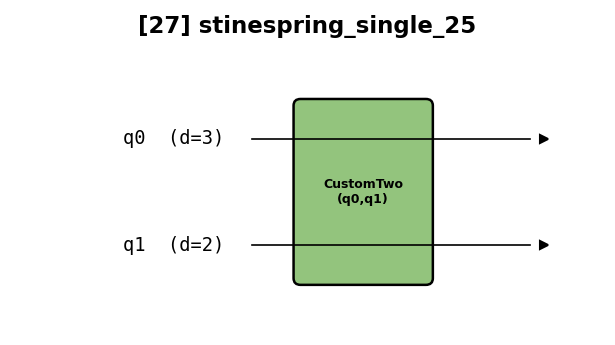


[28] hamiltonian_half_2 -> circuit_images/scenario5_qudit_nb_28_hamiltonian_half_2.png


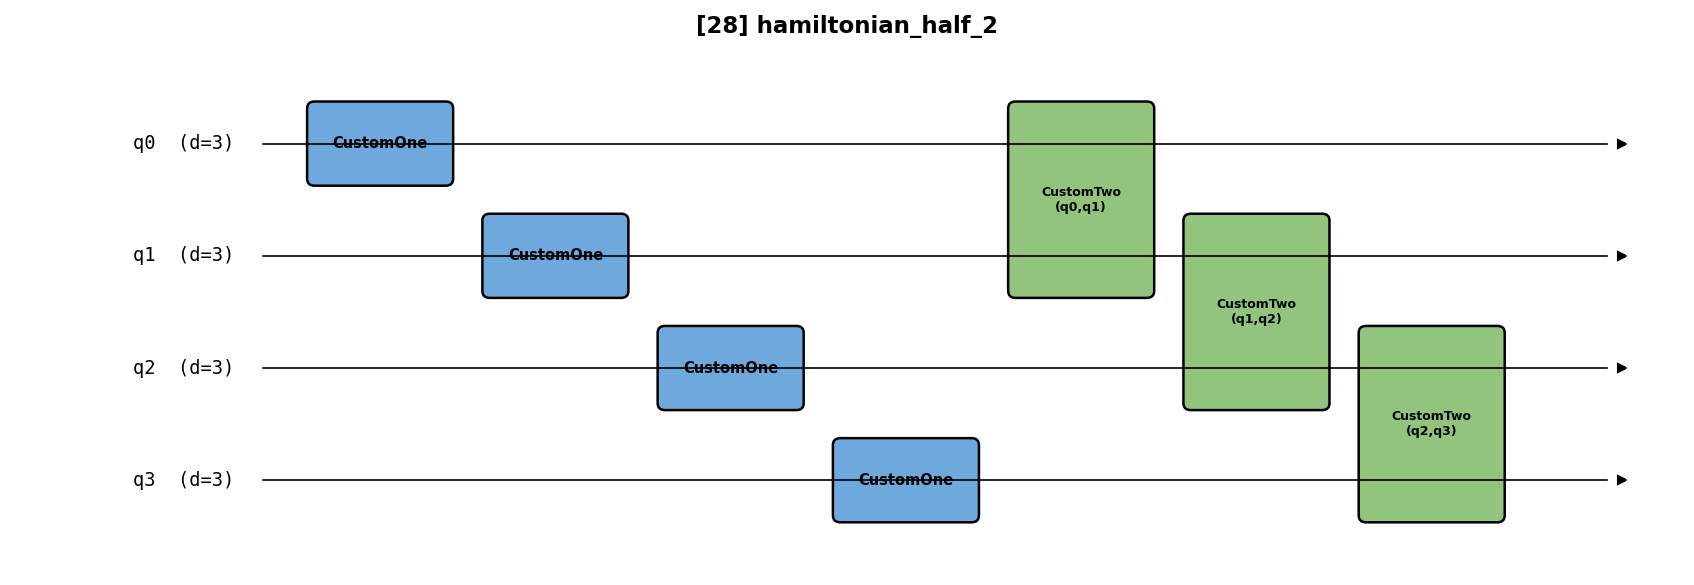


Scenario 6: Qudit GKSL (With Boson) - 1 Trotter Step
subcircuits: 14

[01] hamiltonian_half_1 -> circuit_images/scenario6_qudit_b_01_hamiltonian_half_1.png


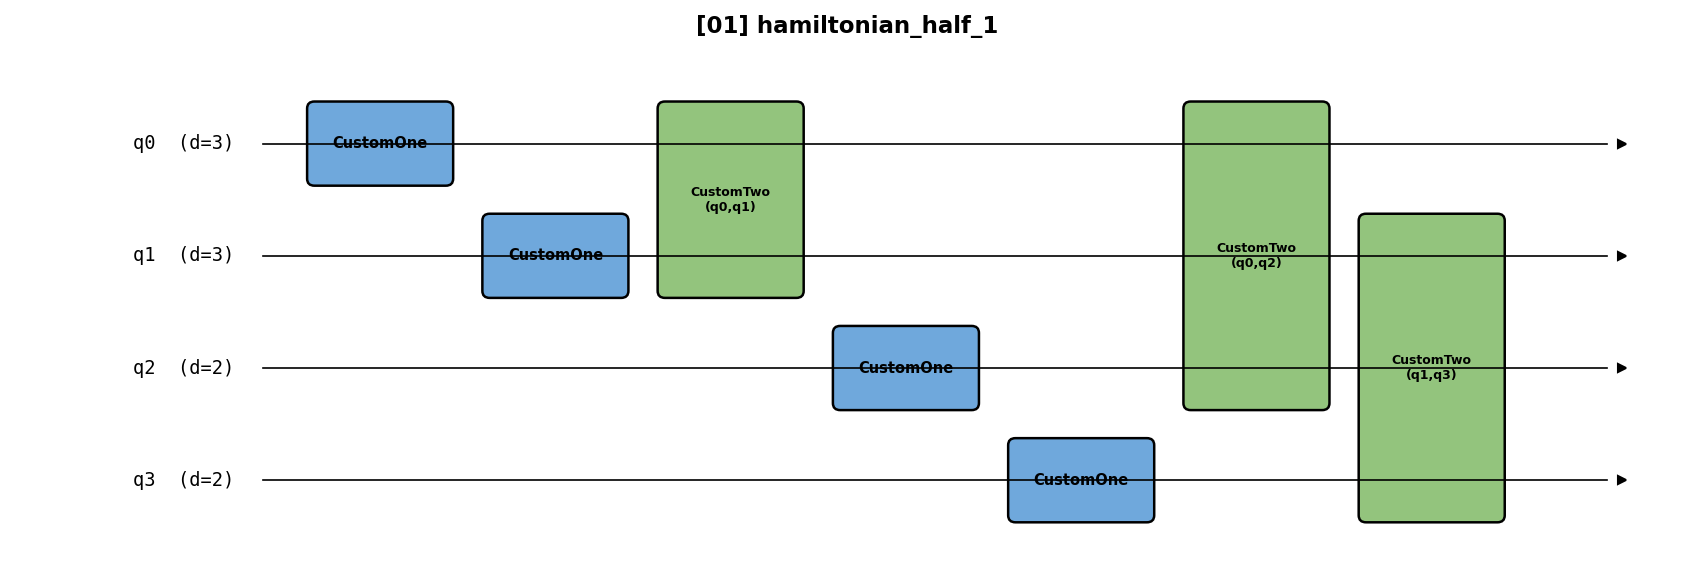


[02] stinespring_pair_0 -> circuit_images/scenario6_qudit_b_02_stinespring_pair_0.png


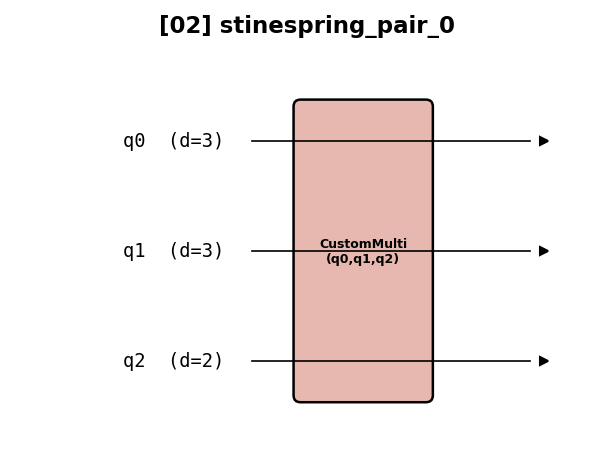


[03] stinespring_pair_1 -> circuit_images/scenario6_qudit_b_03_stinespring_pair_1.png


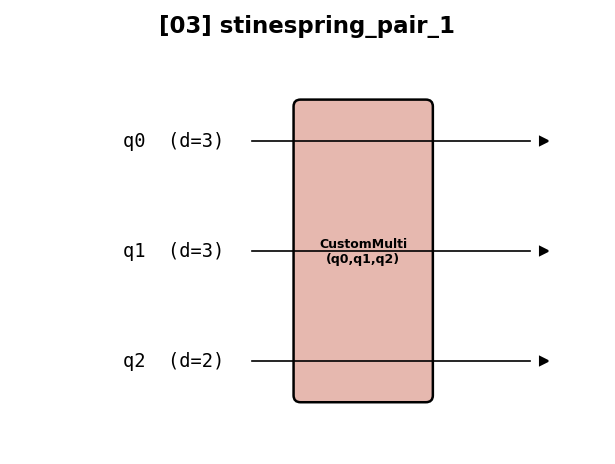


[04] stinespring_single_2 -> circuit_images/scenario6_qudit_b_04_stinespring_single_2.png


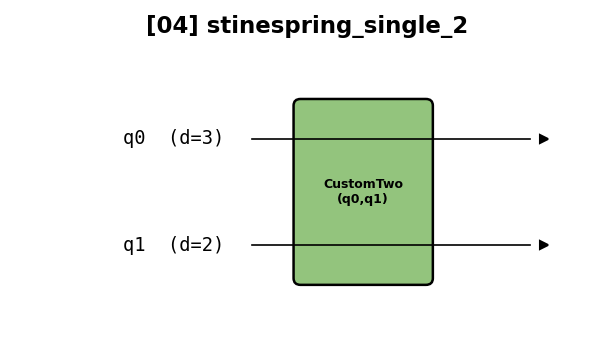


[05] stinespring_single_3 -> circuit_images/scenario6_qudit_b_05_stinespring_single_3.png


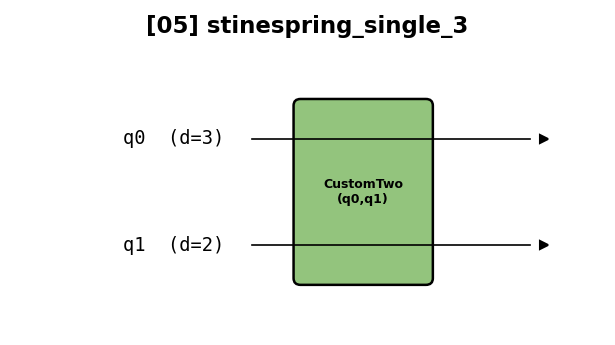


[06] stinespring_single_4 -> circuit_images/scenario6_qudit_b_06_stinespring_single_4.png


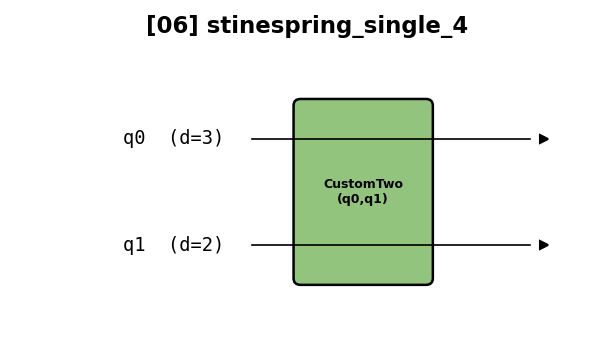


[07] stinespring_single_5 -> circuit_images/scenario6_qudit_b_07_stinespring_single_5.png


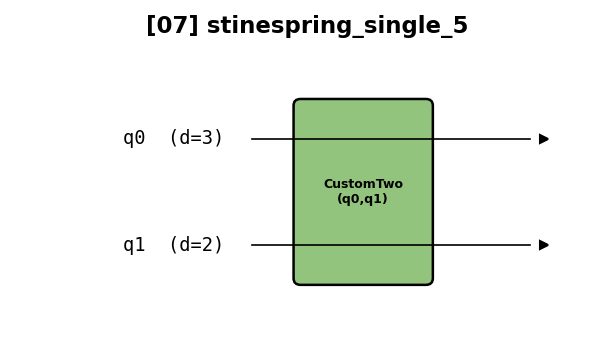


[08] stinespring_single_6 -> circuit_images/scenario6_qudit_b_08_stinespring_single_6.png


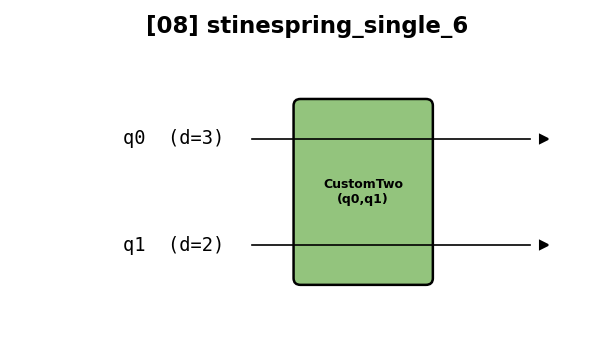


[09] stinespring_single_7 -> circuit_images/scenario6_qudit_b_09_stinespring_single_7.png


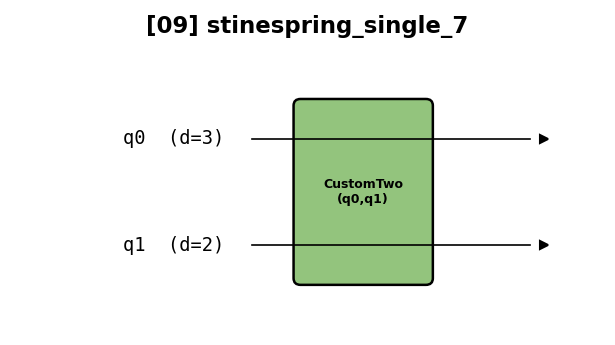


[10] stinespring_single_8 -> circuit_images/scenario6_qudit_b_10_stinespring_single_8.png


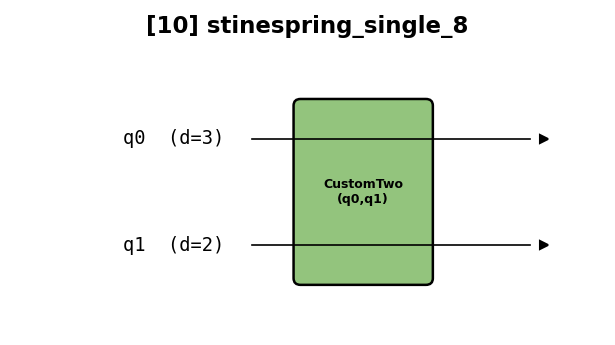


[11] stinespring_single_9 -> circuit_images/scenario6_qudit_b_11_stinespring_single_9.png


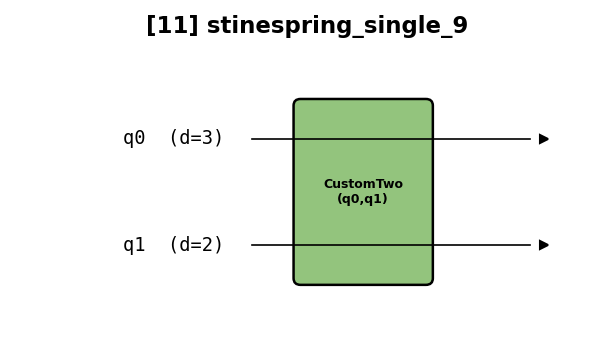


[12] stinespring_single_10 -> circuit_images/scenario6_qudit_b_12_stinespring_single_10.png


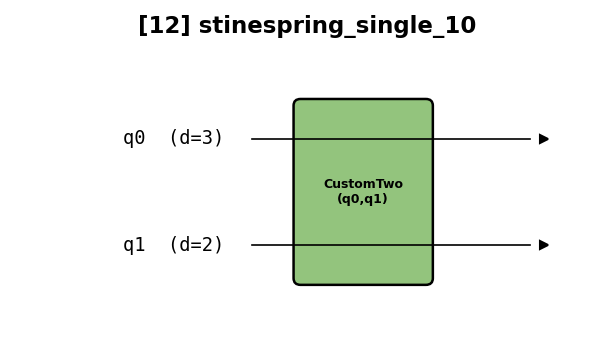


[13] stinespring_single_11 -> circuit_images/scenario6_qudit_b_13_stinespring_single_11.png


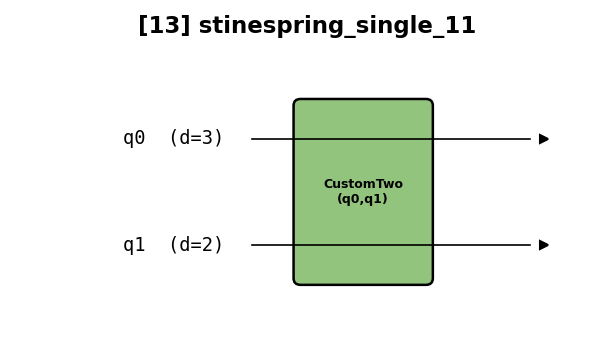


[14] hamiltonian_half_2 -> circuit_images/scenario6_qudit_b_14_hamiltonian_half_2.png


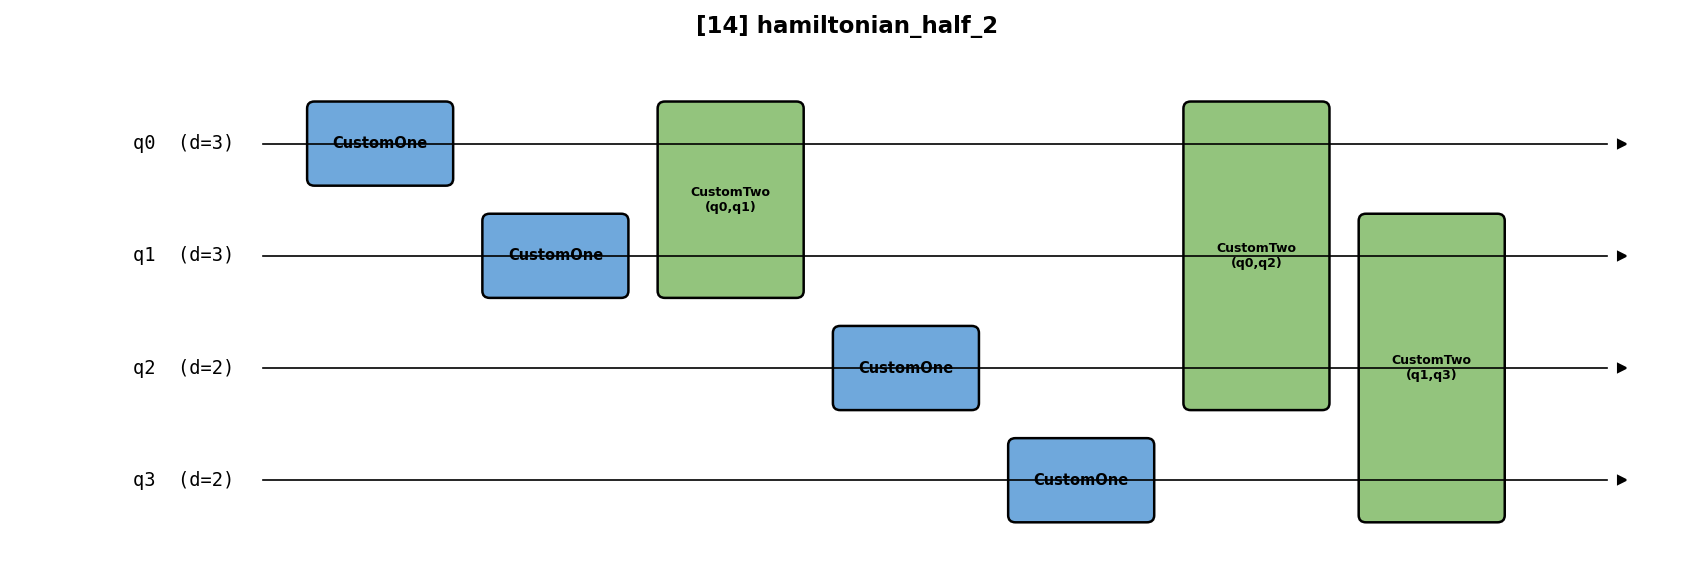


Scenario 4: Qubit GKSL (With Boson) - 1 Trotter Step
subcircuits: 14

[01] hamiltonian_half_1 -> circuit_images/scenario4_qubit_b_01_hamiltonian_half_1.png


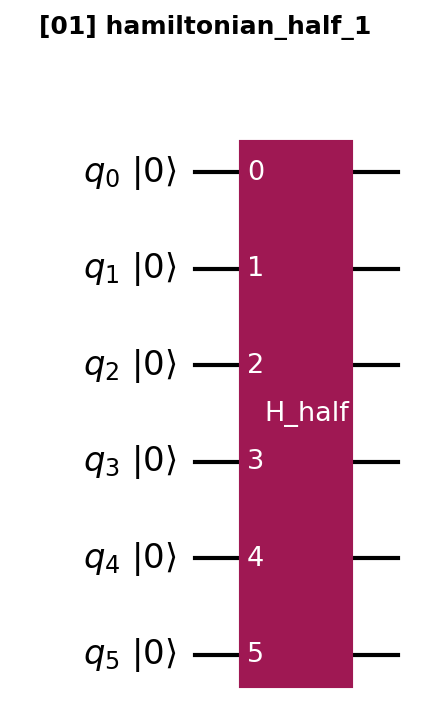


[02] stinespring_0 -> circuit_images/scenario4_qubit_b_02_stinespring_0.png


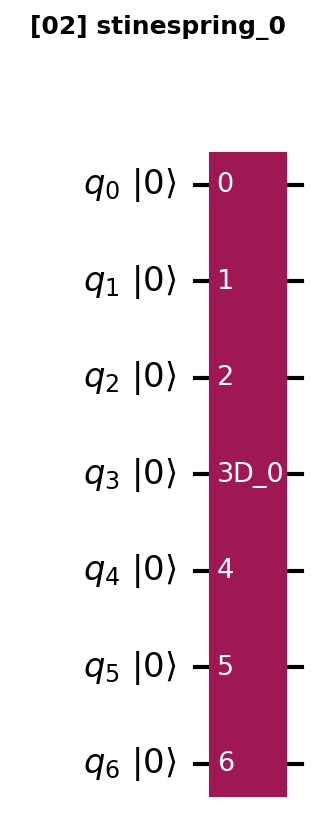


[03] stinespring_1 -> circuit_images/scenario4_qubit_b_03_stinespring_1.png


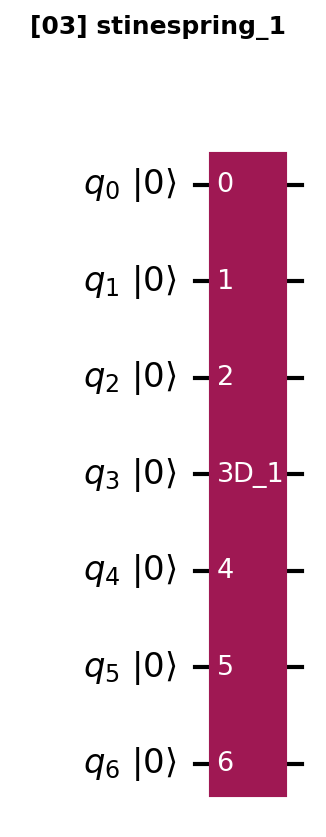


[04] stinespring_2 -> circuit_images/scenario4_qubit_b_04_stinespring_2.png


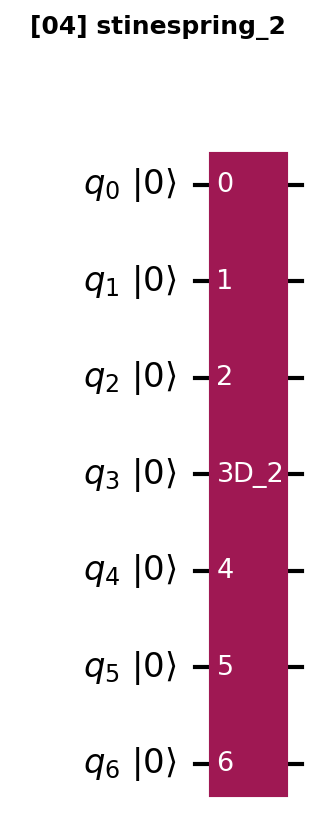


[05] stinespring_3 -> circuit_images/scenario4_qubit_b_05_stinespring_3.png


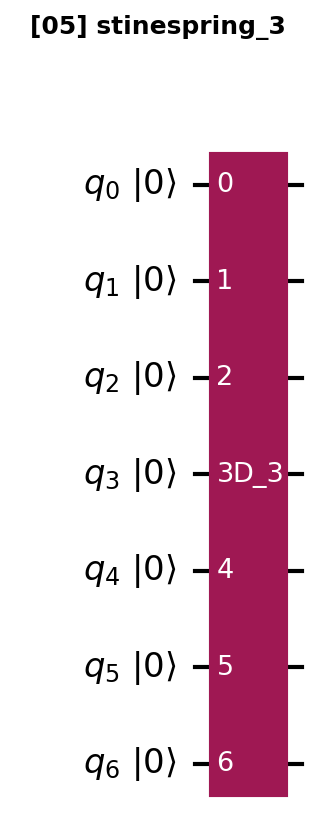


[06] stinespring_4 -> circuit_images/scenario4_qubit_b_06_stinespring_4.png


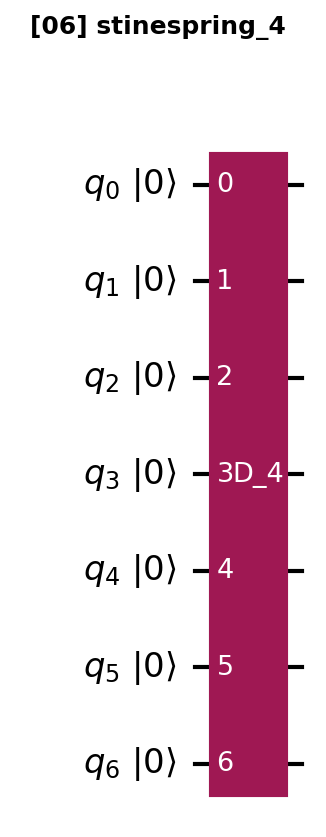


[07] stinespring_5 -> circuit_images/scenario4_qubit_b_07_stinespring_5.png


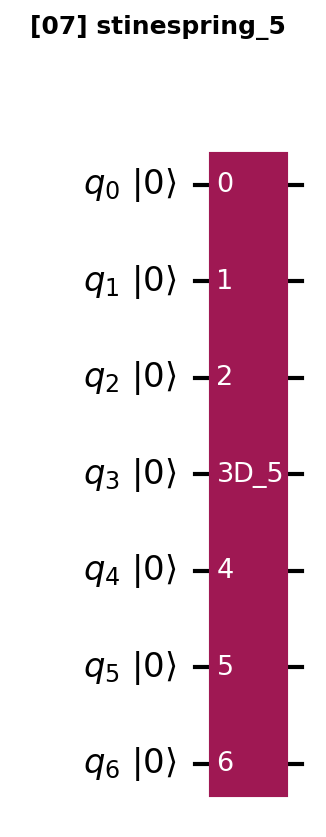


[08] stinespring_6 -> circuit_images/scenario4_qubit_b_08_stinespring_6.png


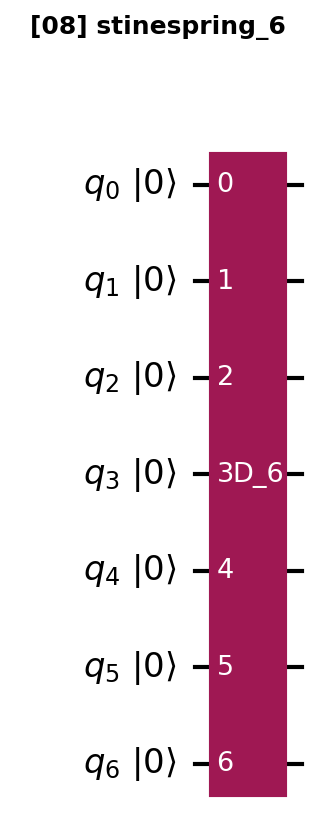


[09] stinespring_7 -> circuit_images/scenario4_qubit_b_09_stinespring_7.png


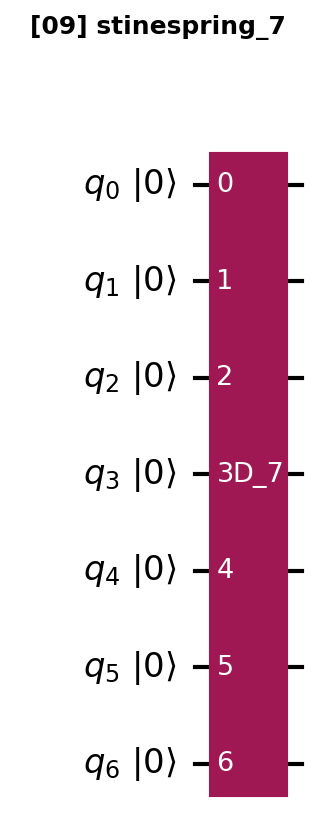


[10] stinespring_8 -> circuit_images/scenario4_qubit_b_10_stinespring_8.png


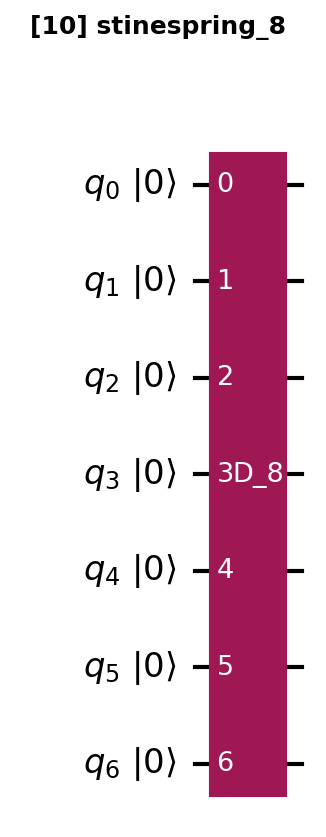


[11] stinespring_9 -> circuit_images/scenario4_qubit_b_11_stinespring_9.png


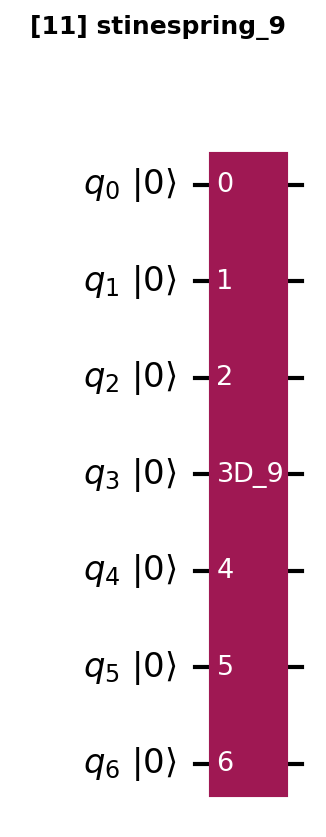


[12] stinespring_10 -> circuit_images/scenario4_qubit_b_12_stinespring_10.png


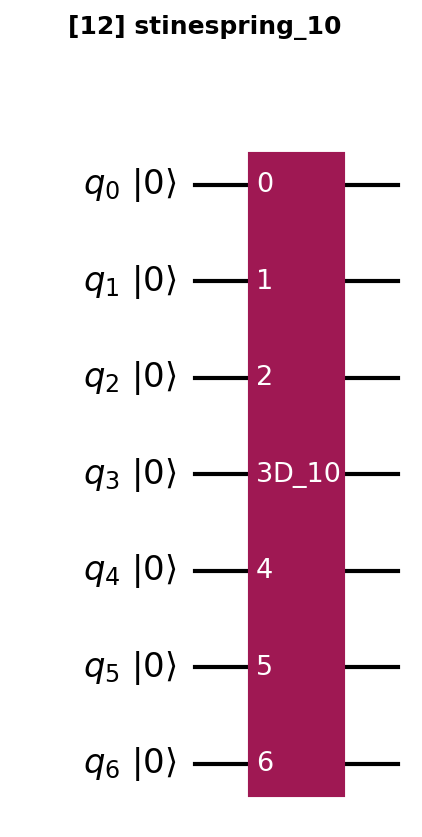


[13] stinespring_11 -> circuit_images/scenario4_qubit_b_13_stinespring_11.png


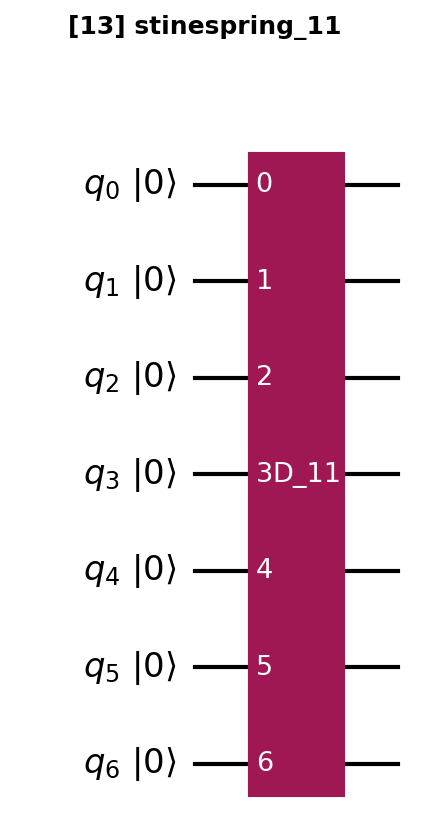


[14] hamiltonian_half_2 -> circuit_images/scenario4_qubit_b_14_hamiltonian_half_2.png


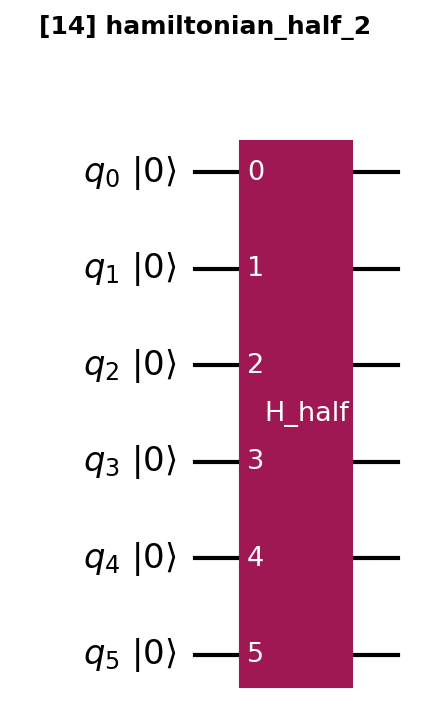

In [8]:
from scipy.linalg import expm
from typing import Protocol

from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
from qiskit.visualization import circuit_drawer

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image

from qubit_gksl_circuit_simulator import QubitGKSLCircuitSimulator
from qudit_gksl_circuit_simulator import QuditGKSLCircuitSimulator
from qudit_gksl_circuit_boson_simulator import QuditGKSLCircuitBosonSimulator
from stinespring_utils import stinespring_unitary_from_lindblad

from mqt.qudits.quantum_circuit.components.extensions.gate_types import GateTypes

# Output directory for PNG files
os.makedirs("circuit_images", exist_ok=True)


def _embed_unitary_to_power_of_two(U: np.ndarray, target_dim: int) -> np.ndarray:
    if U.shape[0] != U.shape[1]:
        raise ValueError("Unitary must be square")
    if target_dim <= 0 or (target_dim & (target_dim - 1)) != 0:
        raise ValueError("Target dimension must be a positive power of two")
    if U.shape[0] > target_dim:
        raise ValueError("Target dimension is smaller than unitary dimension")

    embedded = np.eye(target_dim, dtype=np.complex128)
    embedded[: U.shape[0], : U.shape[1]] = U
    return embedded


class SupportsToQasm(Protocol):
    def to_qasm(self) -> str: ...


def _draw_qiskit_subcircuits(
    title: str,
    named_circuits: list[tuple[str, QuantumCircuit]],
    prefix: str,
) -> None:
    """Draw Qiskit subcircuits using circuit_drawer with mpl output, save as PNG, and display."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    print(f"subcircuits: {len(named_circuits)}")
    for idx, (name, circuit) in enumerate(named_circuits, start=1):
        filename = f"circuit_images/{prefix}_{idx:02d}_{name}.png"
        fig = circuit_drawer(circuit, output="mpl", fold=40, initial_state=True)
        fig.suptitle(f"[{idx:02d}] {name}", fontsize=12, fontweight="bold")
        fig.savefig(filename, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"\n[{idx:02d}] {name} -> {filename}")
        display(Image(filename=filename))


def _draw_qudit_circuit_mpl(
    circuit,
    title: str = "",
    filename: str | None = None,
) -> None:
    """Draw an MQT-Qudits QuantumCircuit using matplotlib.

    Renders a circuit diagram with horizontal qudit wires (labeled with
    dimension) and gate boxes for each instruction. Multi-qudit gates
    span the relevant wires with a single box.

    This provides circuit visualization analogous to qiskit.visualization.circuit_drawer
    but for qudit circuits with heterogeneous dimensions.
    """
    n_qudits = circuit.num_qudits
    dims = circuit.dimensions
    instructions = circuit.instructions
    n_gates = len(instructions)

    # Layout parameters
    wire_spacing = 0.8
    gate_spacing = 1.2
    gate_width = 0.9
    gate_height = 0.5
    margin_left = 2.0
    margin_right = 1.0

    total_width = margin_left + max(n_gates, 1) * gate_spacing + margin_right
    total_height = max(2.0, (n_qudits + 1) * wire_spacing)

    fig, ax = plt.subplots(figsize=(min(total_width, 30), total_height))

    x_start = margin_left
    x_end = x_start + max(n_gates, 1) * gate_spacing + 0.5

    # Draw wires and labels
    for i in range(n_qudits):
        y = (n_qudits - 1 - i) * wire_spacing
        ax.plot([x_start - 0.3, x_end], [y, y], color="black", linewidth=0.8)
        label = f"q{i}  (d={dims[i]})"
        ax.text(
            x_start - 0.5, y, label,
            ha="right", va="center", fontsize=9, fontfamily="monospace",
        )
        # Measurement symbol at the end
        ax.plot(x_end + 0.1, y, "k>", markersize=4)

    # Color map for gate types
    gate_colors = {
        GateTypes.SINGLE: "#6fa8dc",   # Blue for single-qudit gates
        GateTypes.TWO: "#93c47d",      # Green for two-qudit gates
        GateTypes.MULTI: "#e6b8af",    # Pink for multi-qudit gates
    }

    # Draw gates
    for gate_idx, gate in enumerate(instructions):
        x = x_start + gate_idx * gate_spacing + 0.5

        gate_name = type(gate).__name__
        color = gate_colors.get(gate.gate_type, "#d9d9d9")

        if gate.gate_type == GateTypes.SINGLE:
            qudit = gate.target_qudits
            y = (n_qudits - 1 - qudit) * wire_spacing
            rect = mpatches.FancyBboxPatch(
                (x - gate_width / 2, y - gate_height / 2),
                gate_width, gate_height,
                boxstyle="round,pad=0.05",
                facecolor=color, edgecolor="black", linewidth=1.2,
            )
            ax.add_patch(rect)
            ax.text(x, y, gate_name, ha="center", va="center", fontsize=7, fontweight="bold")
        else:
            # Multi-qudit gate
            qudits = gate.target_qudits if isinstance(gate.target_qudits, list) else [gate.target_qudits]
            y_positions = [(n_qudits - 1 - q) * wire_spacing for q in qudits]
            y_min = min(y_positions) - gate_height / 2
            y_max = max(y_positions) + gate_height / 2
            box_height = y_max - y_min

            rect = mpatches.FancyBboxPatch(
                (x - gate_width / 2, y_min),
                gate_width, box_height,
                boxstyle="round,pad=0.05",
                facecolor=color, edgecolor="black", linewidth=1.2,
            )
            ax.add_patch(rect)
            y_center = (y_min + y_max) / 2
            label_text = f"{gate_name}\n({','.join(f'q{q}' for q in qudits)})"
            ax.text(x, y_center, label_text, ha="center", va="center", fontsize=6, fontweight="bold")

    ax.set_xlim(0, x_end + 0.5)
    ax.set_ylim(-wire_spacing * 0.8, (n_qudits - 0.2) * wire_spacing)
    ax.set_aspect("auto")
    ax.axis("off")

    if title:
        ax.set_title(title, fontsize=11, fontweight="bold", pad=10)

    plt.tight_layout()
    if filename:
        fig.savefig(filename, dpi=150, bbox_inches="tight")
    plt.close(fig)


def _draw_qudit_subcircuits(
    title: str,
    named_circuits: list[tuple[str, object]],
    prefix: str,
) -> None:
    """Draw qudit subcircuits using matplotlib, save as PNG, and display."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    print(f"subcircuits: {len(named_circuits)}")
    for idx, (name, circuit) in enumerate(named_circuits, start=1):
        filename = f"circuit_images/{prefix}_{idx:02d}_{name}.png"
        _draw_qudit_circuit_mpl(circuit, title=f"[{idx:02d}] {name}", filename=filename)
        print(f"\n[{idx:02d}] {name} -> {filename}")
        display(Image(filename=filename))


dt_quantum = t_max / n_steps_quantum

# Scenario 3: Qubit GKSL (no boson)
qubit_circuit_sim = QubitGKSLCircuitSimulator(params)
qubit_step_info = qubit_circuit_sim.build_full_trotter_step_circuit(dt_quantum)
_draw_qiskit_subcircuits(
    "Scenario 3: Qubit GKSL (No Boson) - 1 Trotter Step",
    qubit_step_info["circuits"],
    prefix="scenario3_qubit_nb",
)

# Scenario 5: Qudit GKSL (no boson)
qudit_circuit_sim = QuditGKSLCircuitSimulator(params)
qudit_step_info = qudit_circuit_sim.build_full_trotter_step_circuit(dt_quantum)
_draw_qudit_subcircuits(
    "Scenario 5: Qudit GKSL (No Boson) - 1 Trotter Step",
    qudit_step_info["circuits"],
    prefix="scenario5_qudit_nb",
)

# Scenario 6: Qudit GKSL (with boson)
qudit_boson_circuit_sim = QuditGKSLCircuitBosonSimulator(params_boson)
qudit_boson_step_circuits: list[tuple[str, SupportsToQasm]] = []

h1, _ = qudit_boson_circuit_sim.build_hamiltonian_circuit(dt_quantum / 2)
qudit_boson_step_circuits.append(("hamiltonian_half_1", h1))

for idx, (op_type, sites, L_local, _gamma) in enumerate(qudit_boson_circuit_sim.lindblad_local_info):
    if op_type == "single":
        circ, _ = qudit_boson_circuit_sim.build_stinespring_circuit_single(
            L_local, dt_quantum, sites[0]
        )
        qudit_boson_step_circuits.append((f"stinespring_single_{idx}", circ))
    elif op_type == "pair":
        circ, _ = qudit_boson_circuit_sim.build_stinespring_circuit_pair(
            L_local, dt_quantum, sites[0], sites[1]
        )
        qudit_boson_step_circuits.append((f"stinespring_pair_{idx}", circ))

h2, _ = qudit_boson_circuit_sim.build_hamiltonian_circuit(dt_quantum / 2)
qudit_boson_step_circuits.append(("hamiltonian_half_2", h2))

_draw_qudit_subcircuits(
    "Scenario 6: Qudit GKSL (With Boson) - 1 Trotter Step",
    qudit_boson_step_circuits,
    prefix="scenario6_qudit_b",
)

# Scenario 4: Qubit GKSL (with boson)
n_sys_qubits_boson = sim4.n_el_qubits + sim4.n_ph_qubits
dim_sys_boson = 2 ** n_sys_qubits_boson

qubit_boson_step_circuits: list[tuple[str, QuantumCircuit]] = []

U_half = expm(-1j * sim4.H_total * (dt_quantum / 2))
U_half_embedded = _embed_unitary_to_power_of_two(U_half, dim_sys_boson)

ham1 = QuantumCircuit(n_sys_qubits_boson)
ham1.append(UnitaryGate(U_half_embedded, label="H_half"), range(n_sys_qubits_boson))
qubit_boson_step_circuits.append(("hamiltonian_half_1", ham1))

for idx, (L_op, _gamma) in enumerate(sim4.lindblad_ops):
    U_stinespring = stinespring_unitary_from_lindblad(L_op, dt_quantum)
    U_stinespring_embedded = _embed_unitary_to_power_of_two(
        U_stinespring, 2 * dim_sys_boson
    )

    channel_circuit = QuantumCircuit(n_sys_qubits_boson + 1)
    channel_circuit.append(
        UnitaryGate(U_stinespring_embedded, label=f"D_{idx}"),
        range(n_sys_qubits_boson + 1),
    )
    qubit_boson_step_circuits.append((f"stinespring_{idx}", channel_circuit))

ham2 = QuantumCircuit(n_sys_qubits_boson)
ham2.append(UnitaryGate(U_half_embedded, label="H_half"), range(n_sys_qubits_boson))
qubit_boson_step_circuits.append(("hamiltonian_half_2", ham2))

_draw_qiskit_subcircuits(
    "Scenario 4: Qubit GKSL (With Boson) - 1 Trotter Step",
    qubit_boson_step_circuits,
    prefix="scenario4_qubit_b",
)


## 8. 全シナリオの包括的比較

ボソン無しの3シナリオ（同一パラメータ）とボソン有りの3シナリオ（同一パラメータ）を
それぞれ比較します。

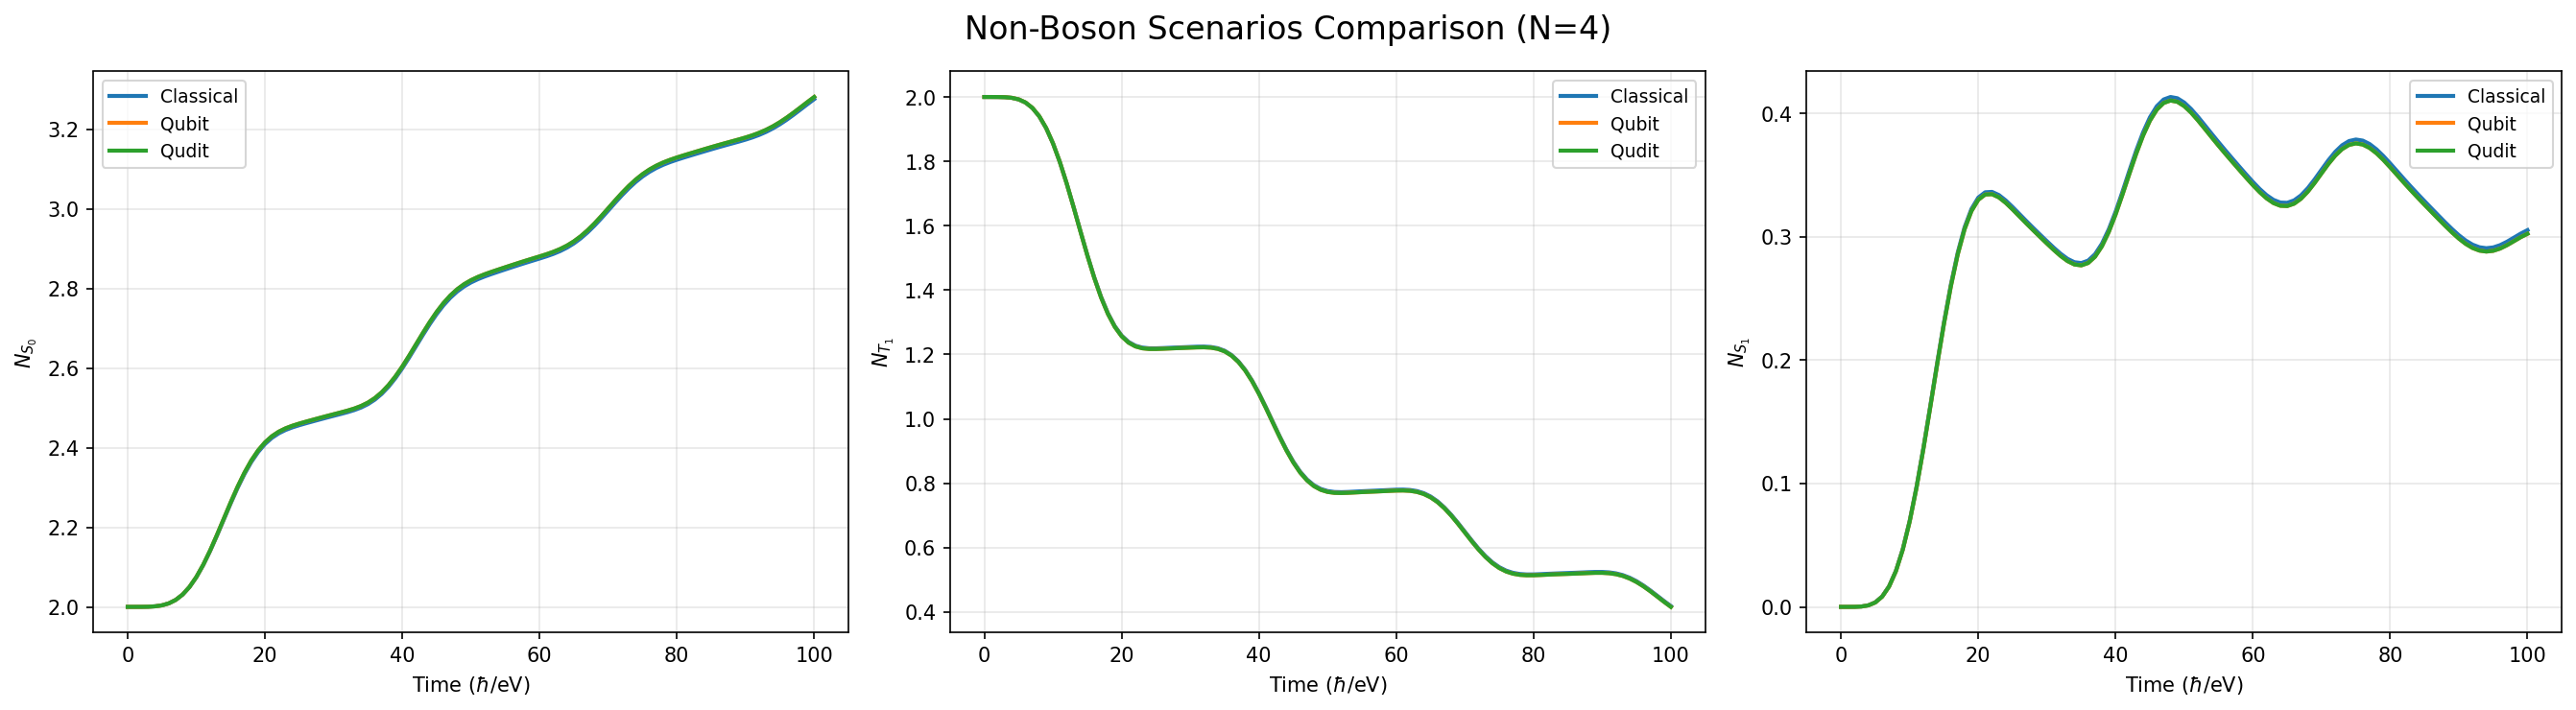

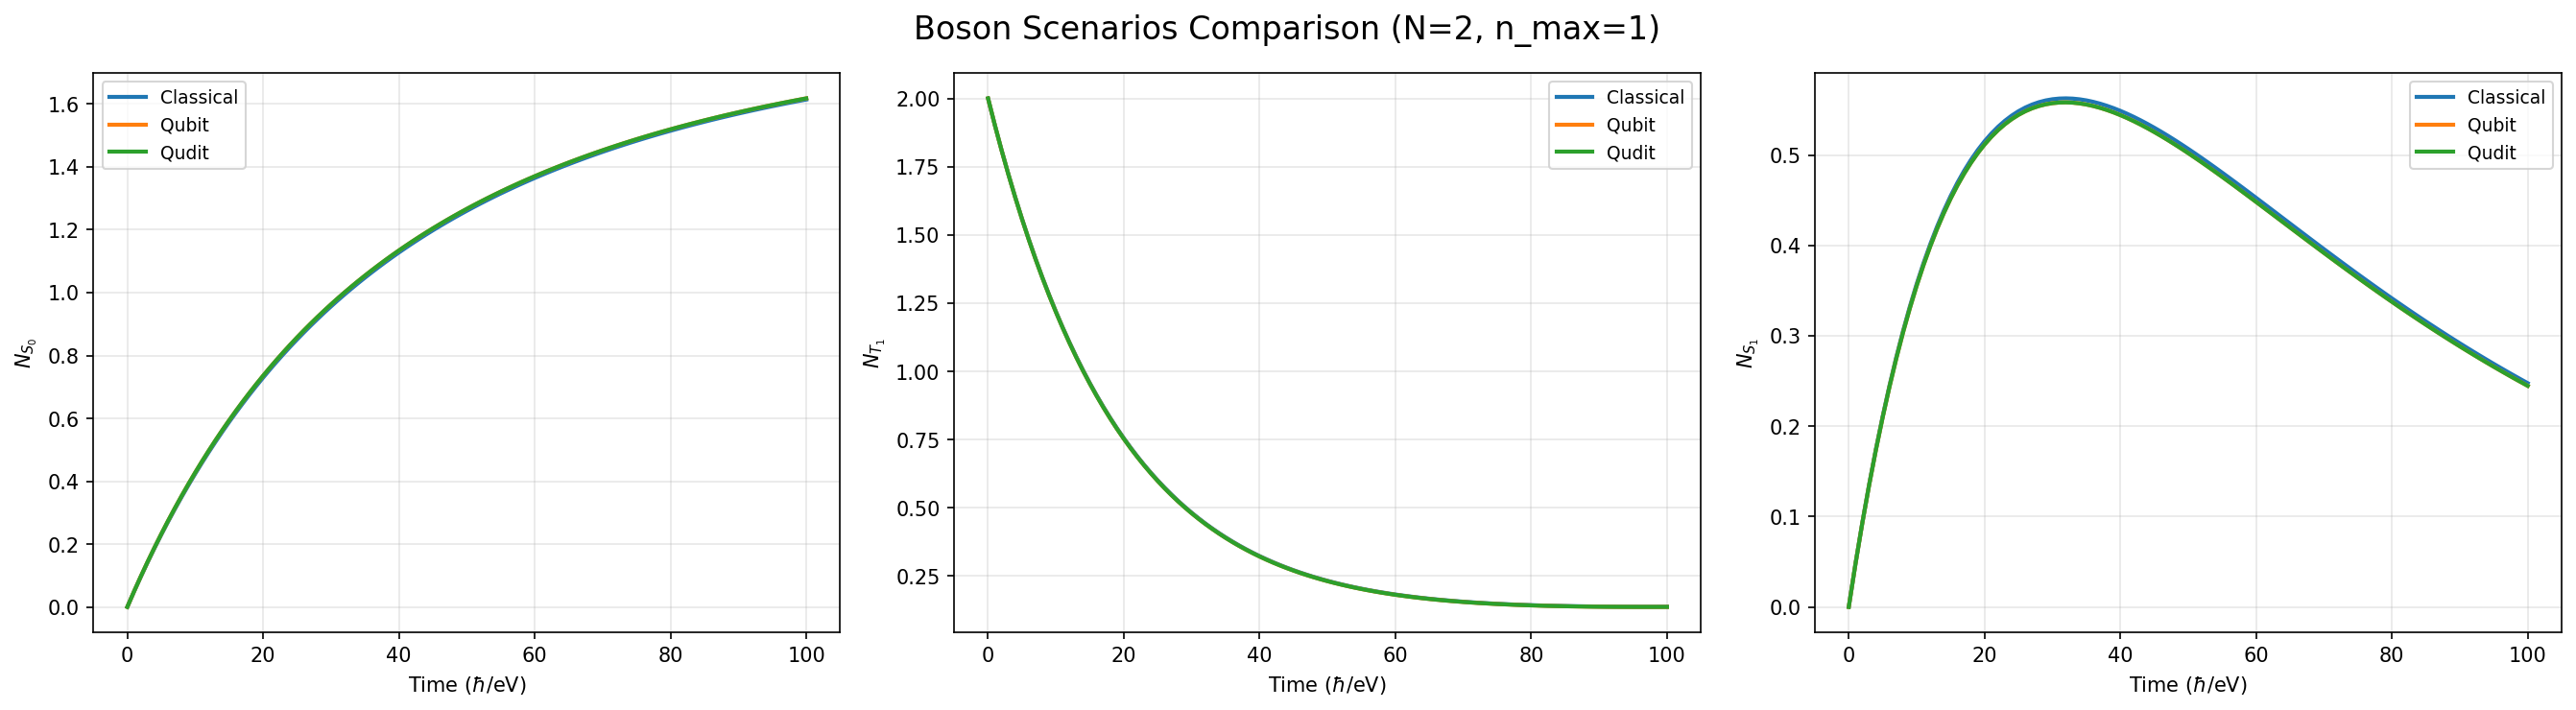

In [9]:
from gksl_visualization import compare_multiple_scenarios
from IPython.display import display, Image

# Non-boson comparison (all use same 81-dim Hilbert space)
results_nb = {
    'Classical': result1,
    'Qubit': result3,
    'Qudit': result5,
}
compare_multiple_scenarios(results_nb, title='Non-Boson Scenarios Comparison (N=4)',
                           save_path='circuit_images/comparison_non_boson.png')
display(Image(filename='circuit_images/comparison_non_boson.png'))

# Boson comparison (N=2, n_max=1)
results_b = {
    'Classical': result2,
    'Qubit': result4,
    'Qudit': result6,
}
compare_multiple_scenarios(results_b, title='Boson Scenarios Comparison (N=2, n_max=1)',
                           save_path='circuit_images/comparison_boson.png')
display(Image(filename='circuit_images/comparison_boson.png'))


## 9. ユニタリ vs GKSL-Lindblad 比較

全散逸率を0にした純ユニタリ発展（閉量子系）と、
散逸ありのGKSL-Lindblad発展（開量子系）を比較します。

Unitary: max entropy = 2.22e-16 (should be ~0)
GKSL: final entropy = 1.7048


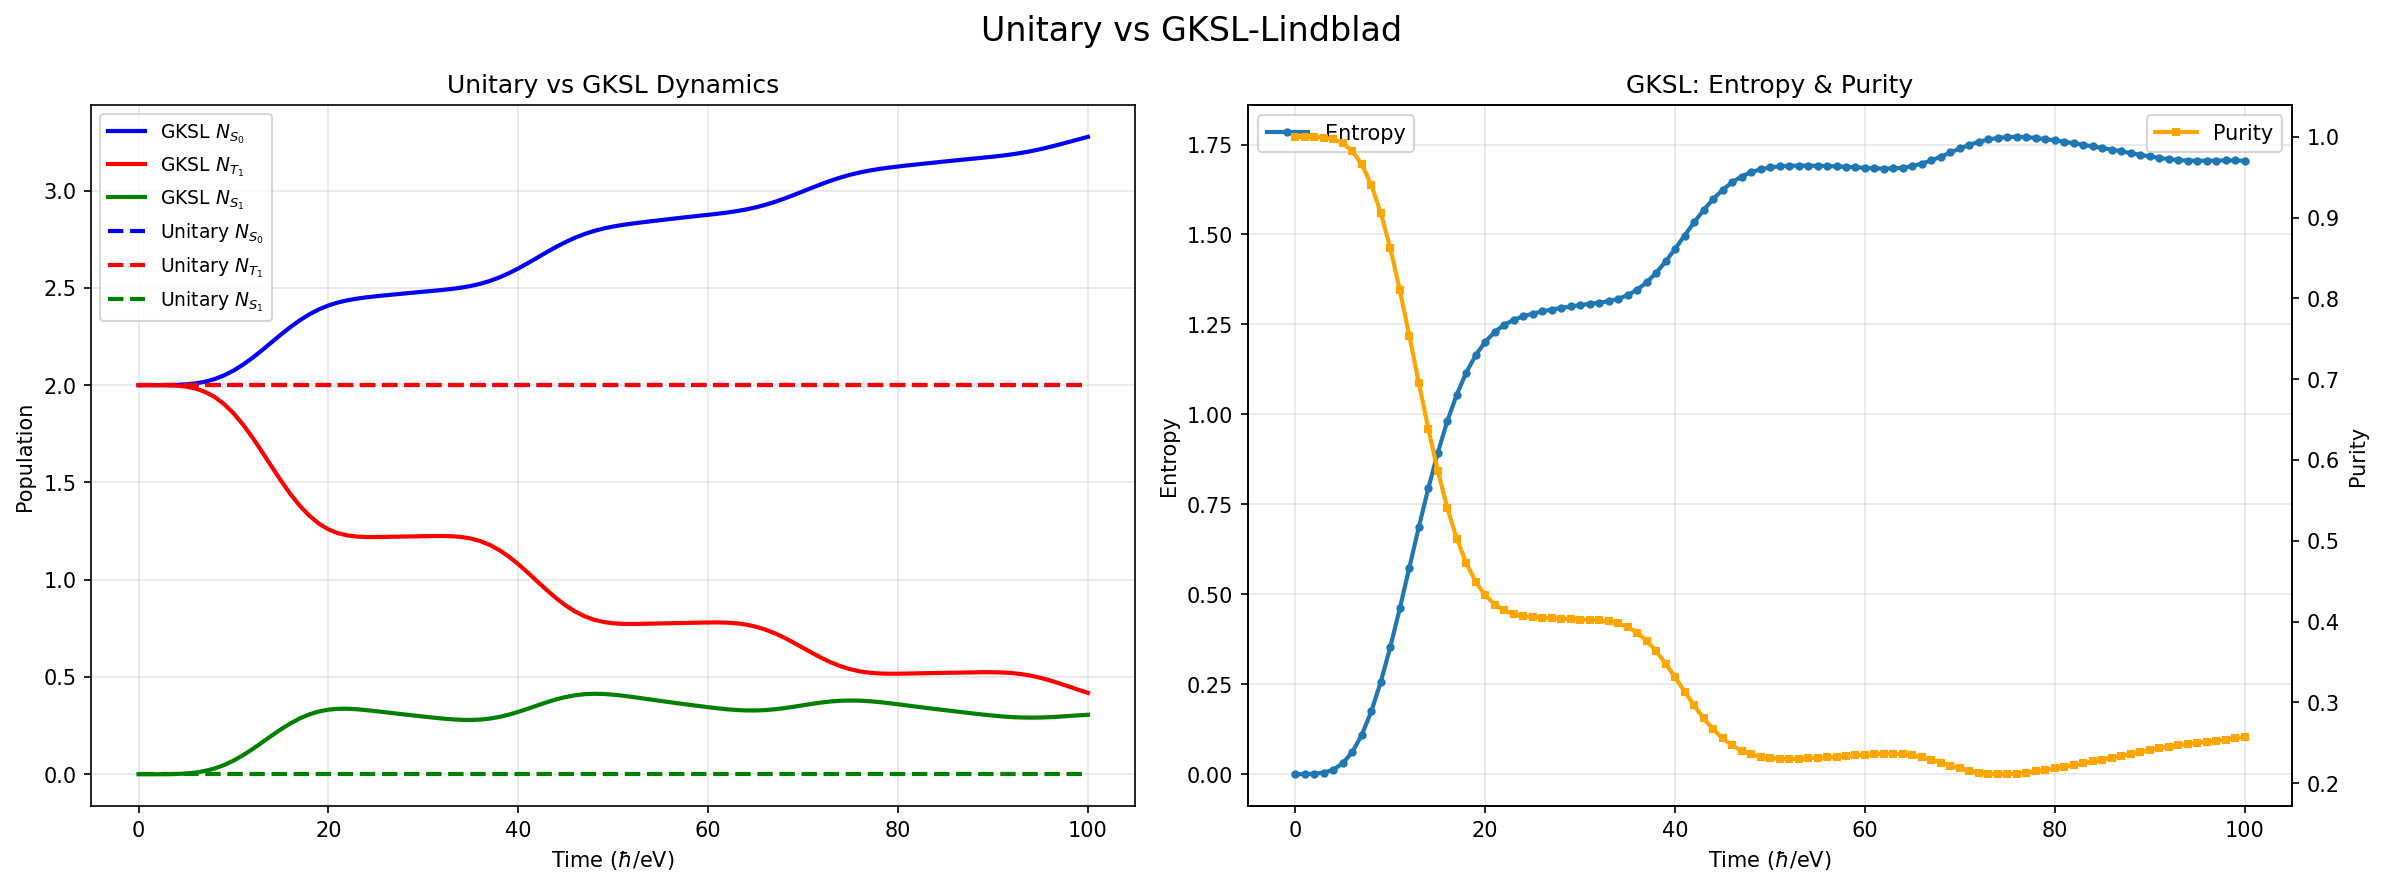

In [10]:
from gksl_visualization import plot_gksl_comparison
from IPython.display import display, Image

# Unitary limit (all dissipation rates = 0)
params_unitary = GKSLPhysicalParameters(
    gamma_TTA=0, Gamma_fl=0, Gamma_ph=0,
    k_IC=0, k_ISC_ST=0, k_ISC_TS=0,
)
sim_unitary = ClassicalGKSLSimulator(params_unitary)
result_unitary = sim_unitary.simulate(t_max=t_max, n_steps=n_steps, initial_state='edge_triplet')

print(f'Unitary: max entropy = {max(result_unitary["entropy"]):.2e} (should be ~0)')
print(f'GKSL: final entropy = {result1["entropy"][-1]:.4f}')

plot_gksl_comparison(result_unitary, result1, title='Unitary vs GKSL-Lindblad',
                     save_path='circuit_images/unitary_vs_gksl.png')
display(Image(filename='circuit_images/unitary_vs_gksl.png'))


## 10. 検証と考察

=== Trace conservation |Tr[ρ]-1| ===
  Classical NB: 5.33e-15
  Classical B: 5.77e-15
  Qubit NB: 8.22e-15
  Qubit B: 1.33e-14
  Qudit NB: 8.44e-15
  Qudit B: 1.33e-14

=== Particle conservation |N_total - N_molecules| ===
  Classical NB: 2.22e-14
  Qubit NB: 3.38e-14
  Qudit NB: 3.46e-14

=== Computation time ===
  Classical NB: 22.44s
  Classical B: 0.27s
  Qubit NB: 20.10s
  Qubit B: 2.52s
  Qudit NB: 7.50s
  Qudit B: 0.58s


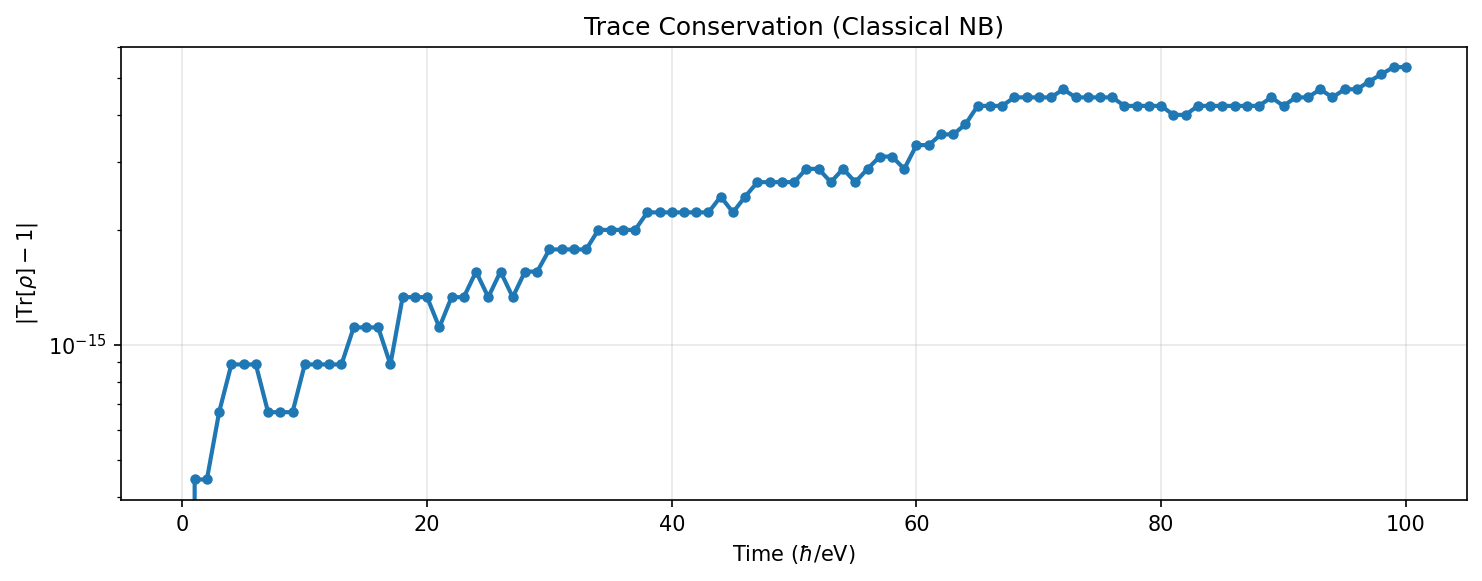

In [11]:
from gksl_visualization import plot_trace_conservation
from IPython.display import display, Image

# Trace conservation check for all scenarios
print('=== Trace conservation |Tr[ρ]-1| ===')
for name, result in [('Classical NB', result1), ('Classical B', result2),
                     ('Qubit NB', result3), ('Qubit B', result4),
                     ('Qudit NB', result5), ('Qudit B', result6)]:
    max_dev = max(abs(t - 1.0) for t in result['trace'])
    print(f'  {name}: {max_dev:.2e}')

print()
print('=== Particle conservation |N_total - N_molecules| ===')
for name, result in [('Classical NB', result1), ('Qubit NB', result3),
                     ('Qudit NB', result5)]:
    N_mol = 4
    max_dev = max(abs(p['N_S0']+p['N_T1']+p['N_S1']-N_mol) for p in result['populations'])
    print(f'  {name}: {max_dev:.2e}')

print()
print('=== Computation time ===')
for name, result in [('Classical NB', result1), ('Classical B', result2),
                     ('Qubit NB', result3), ('Qubit B', result4),
                     ('Qudit NB', result5), ('Qudit B', result6)]:
    print(f'  {name}: {result["elapsed_time"]:.2f}s')

# Trace conservation plot for classical reference
plot_trace_conservation(result1, title='Trace Conservation (Classical NB)',
                        save_path='circuit_images/trace_conservation.png')
display(Image(filename='circuit_images/trace_conservation.png'))


## 11. Stinespring忠実度の評価

古典ODE結果（理想値）とStinespring+Trotter結果の量子忠実度を計算します。

$$F(\hat{\rho}, \hat{\sigma}) = \left(\mathrm{Tr}\sqrt{\sqrt{\hat{\rho}}\hat{\sigma}\sqrt{\hat{\rho}}}\right)^2$$

In [12]:
def quantum_fidelity(rho, sigma):
    """Compute quantum state fidelity via eigendecomposition."""
    evals, evecs = np.linalg.eigh(rho)
    evals = np.maximum(evals, 0.0)
    sqrt_rho = evecs @ np.diag(np.sqrt(evals)) @ evecs.conj().T
    M = sqrt_rho @ sigma @ sqrt_rho
    M = (M + M.conj().T) / 2
    evals_M = np.linalg.eigvalsh(M)
    evals_M = np.maximum(evals_M, 0.0)
    return float(min(np.real(np.sum(np.sqrt(evals_M))) ** 2, 1.0))

# Compare classical vs quantum final density matrices (non-boson)
F_qudit = quantum_fidelity(result1['rho_final'], result5['rho_final'])
F_qubit = quantum_fidelity(result1['rho_final'], result3['rho_final'])

print(f'Fidelity (Classical vs Qudit): F = {F_qudit:.6f}')
print(f'Fidelity (Classical vs Qubit): F = {F_qubit:.6f}')
print(f'Fidelity (Qubit vs Qudit):     F = {quantum_fidelity(result3["rho_final"], result5["rho_final"]):.6f}')

Fidelity (Classical vs Qudit): F = 0.999974
Fidelity (Classical vs Qubit): F = 0.999974
Fidelity (Qubit vs Qudit):     F = 1.000000


## 12b. ショットベースシミュレーション（量子軌道法）

シナリオ3, 5のQubit/Quditシミュレーションは密度行列レベル（Statevector）のシミュレーションです。
ここでは同じStinespring + Trotter分解を**ショットベース**で実行します。

### 量子軌道法（Quantum Trajectory Method）

密度行列 $\hat{\rho}$ の代わりに純粋状態 $|\psi\rangle$ を発展させます：

1. 各トロッターステップで、ハミルトニアンユニタリを適用
2. 各Lindbladチャネルについて、Stinespringユニタリ適用後にアンシラを**測定**（Born則に従い確率的に分岐）
3. 全ステップ終了後、システムを計算基底で**測定**
4. 上記を $N_{\text{shots}}$ 回繰り返し、統計を収集

無限ショット極限で密度行列シミュレーションと一致します：
$$\hat{\rho} = \lim_{N\to\infty} \frac{1}{N} \sum_{k=1}^{N} |\psi_k\rangle\langle\psi_k|$$

### 実行するシナリオ

| シナリオ | 手法 | ノイズ | シミュレータ |
|----------|------|--------|------------|
| 5b | Qudit Shot-based | なし | QuditGKSLShotSimulator |
| 5c | Qudit Shot-based | 脱分極+位相緩和 | QuditGKSLNoisyShotSimulator |
| 3b | Qubit Shot-based | なし | QubitGKSLShotSimulator |
| 3c | Qubit Shot-based | 脱分極+位相緩和 | QubitGKSLNoisyShotSimulator |

### シナリオ5b: Qudit ショットベース（ノイズ無し）

理想的なゲート操作でのショットベースシミュレーション。
有限ショット数による統計的揺らぎのみが密度行列結果との差異要因です。

Elapsed time: 50.61s
Shots: 1000
Final populations: N_S0=3.3100, N_T1=0.3780, N_S1=0.3120
Trace conservation: max|Tr-1| = 2.07e-14
Measurement counts (top 5): {0: 459, 18: 135, 6: 122, 12: 97, 54: 28}


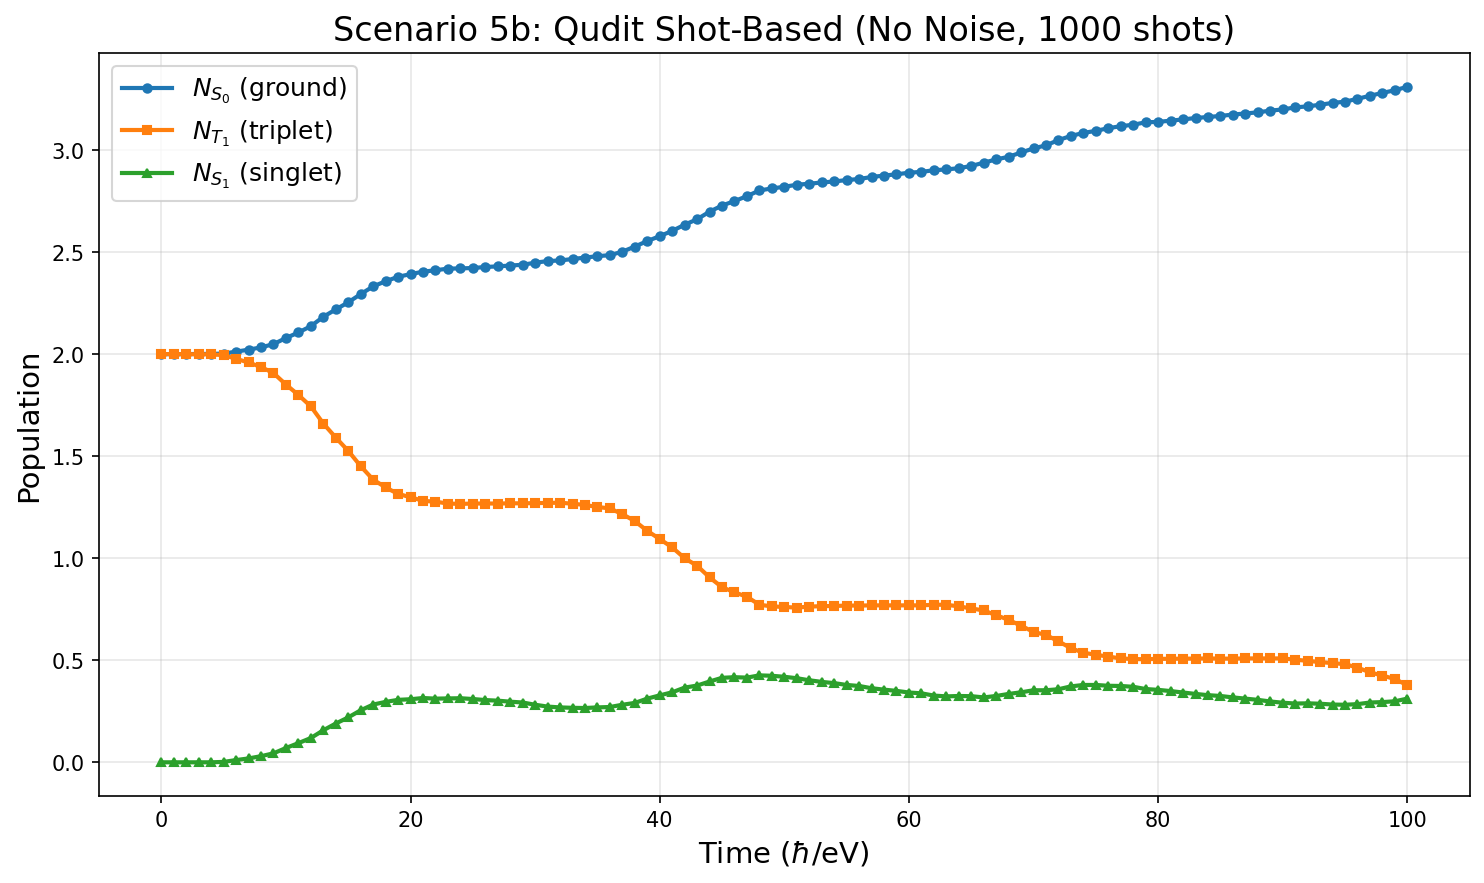

In [13]:
from qudit_gksl_shot_simulator import QuditGKSLShotSimulator
from IPython.display import display, Image

n_shots = 1000

sim5b = QuditGKSLShotSimulator(params)
result5b = sim5b.simulate(
    t_max=t_max, n_steps=n_steps_quantum,
    initial_state='edge_triplet', n_shots=n_shots, seed=42,
)

print(f'Elapsed time: {result5b["elapsed_time"]:.2f}s')
print(f'Shots: {result5b["n_shots"]}')
print(f'Final populations: N_S0={result5b["populations"][-1]["N_S0"]:.4f}, '
      f'N_T1={result5b["populations"][-1]["N_T1"]:.4f}, '
      f'N_S1={result5b["populations"][-1]["N_S1"]:.4f}')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result5b["trace"]):.2e}')
print(f'Measurement counts (top 5): '
      f'{dict(sorted(result5b["counts"].items(), key=lambda x: -x[1])[:5])}')

plot_population_dynamics(result5b, title=f'Scenario 5b: Qudit Shot-Based (No Noise, {n_shots} shots)',
                         save_path='circuit_images/scenario5b_population.png')
display(Image(filename='circuit_images/scenario5b_population.png'))


### シナリオ5c: Qudit ショットベース（ノイズ有り）

各2-quditゲート後に確率的な脱分極ノイズ ($p_{depol}=0.01$) と位相緩和ノイズ ($p_{dephasing}=0.005$) を適用。
Weyl-Heisenberg演算子 $X^a Z^b$ の確率的適用による純粋状態レベルのノイズモデル。

Elapsed time: 59.91s
Noise: p_depol=0.01, p_dephasing=0.005
Final populations: N_S0=1.6389, N_T1=1.1859, N_S1=1.1752


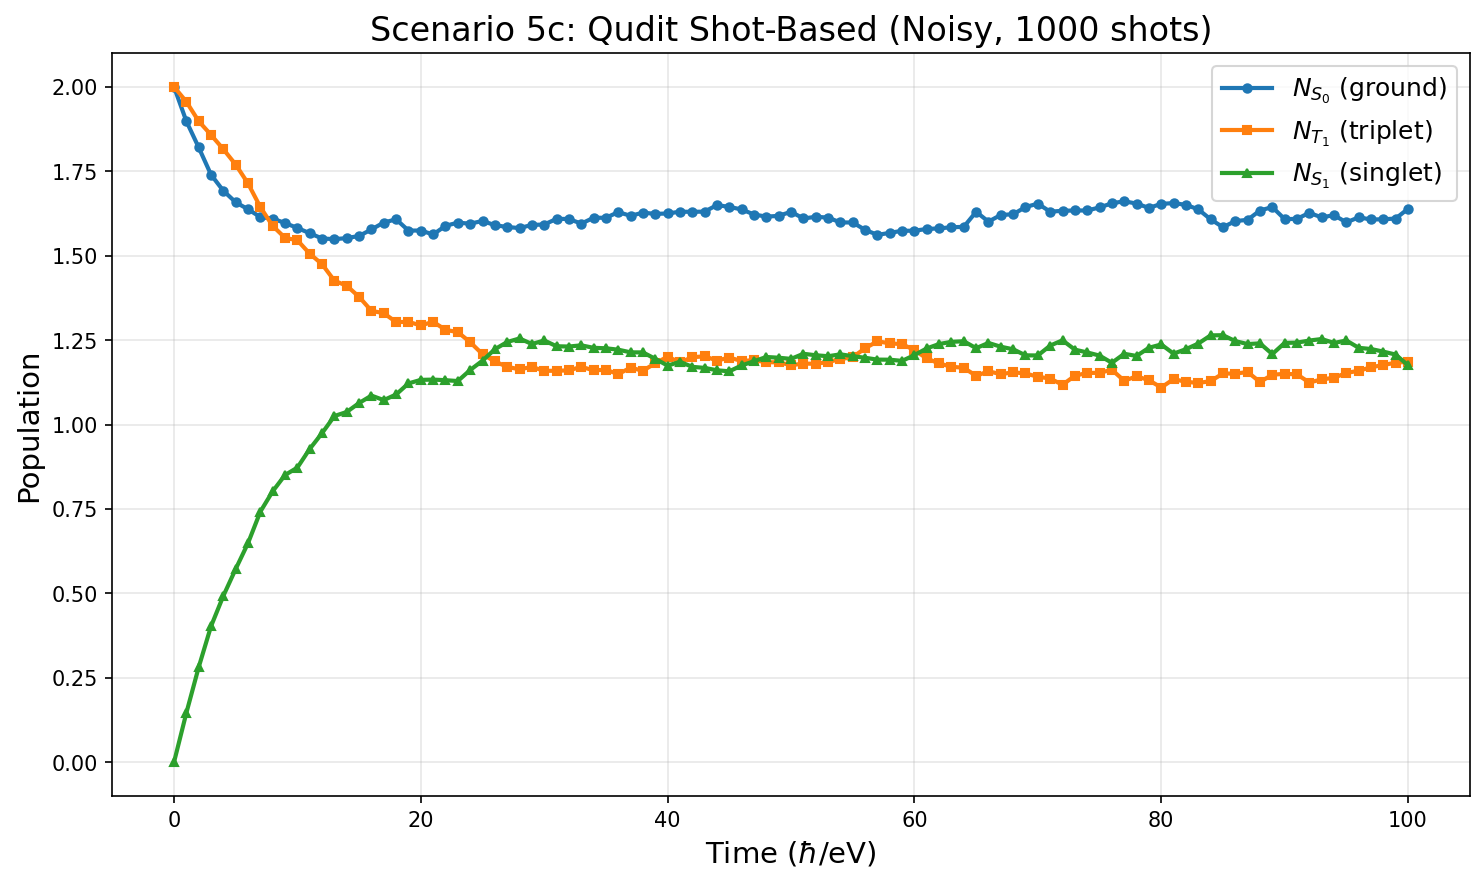

In [14]:
from qudit_gksl_shot_simulator import QuditGKSLNoisyShotSimulator
from IPython.display import display, Image

sim5c = QuditGKSLNoisyShotSimulator(params, p_depol=0.01, p_dephasing=0.005)
result5c = sim5c.simulate(
    t_max=t_max, n_steps=n_steps_quantum,
    initial_state='edge_triplet', n_shots=n_shots, seed=42,
)

print(f'Elapsed time: {result5c["elapsed_time"]:.2f}s')
print(f'Noise: p_depol={result5c["noise_params"]["p_depol"]}, '
      f'p_dephasing={result5c["noise_params"]["p_dephasing"]}')
print(f'Final populations: N_S0={result5c["populations"][-1]["N_S0"]:.4f}, '
      f'N_T1={result5c["populations"][-1]["N_T1"]:.4f}, '
      f'N_S1={result5c["populations"][-1]["N_S1"]:.4f}')

plot_population_dynamics(result5c, title=f'Scenario 5c: Qudit Shot-Based (Noisy, {n_shots} shots)',
                         save_path='circuit_images/scenario5c_population.png')
display(Image(filename='circuit_images/scenario5c_population.png'))


### シナリオ3b: Qubit ショットベース（ノイズ無し）

2-qubitエンコーディングでのショットベースシミュレーション（理想ゲート）。

Elapsed time: 136.99s
Shots: 1000
System qubits: 8
Final populations: N_S0=3.3100, N_T1=0.3780, N_S1=0.3120


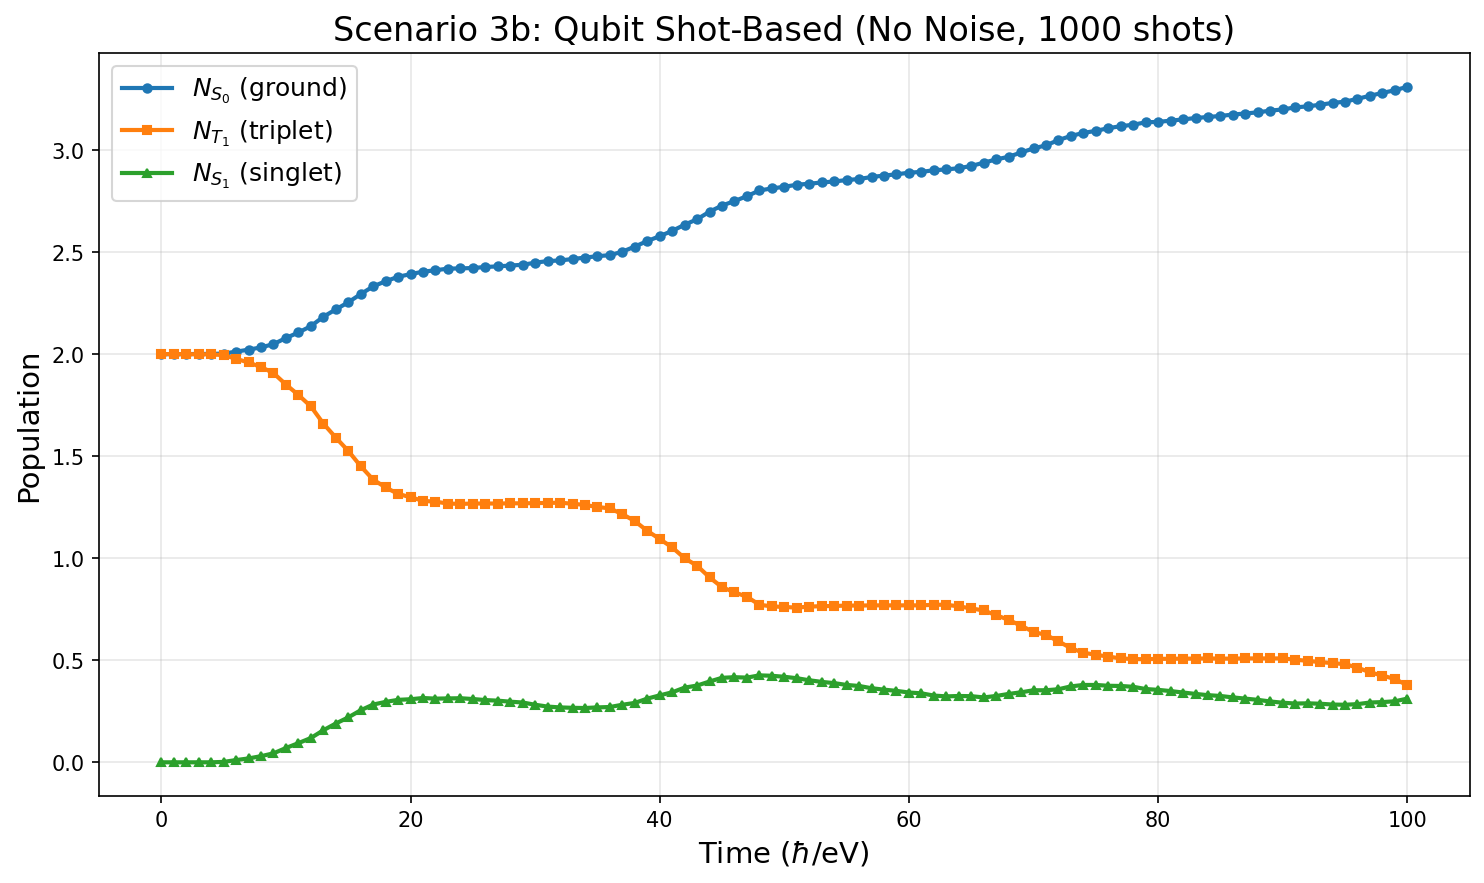

In [15]:
from qubit_gksl_shot_simulator import QubitGKSLShotSimulator
from IPython.display import display, Image

sim3b = QubitGKSLShotSimulator(params)
result3b = sim3b.simulate(
    t_max=t_max, n_steps=n_steps_quantum,
    initial_state='edge_triplet', n_shots=n_shots, seed=42,
)

print(f'Elapsed time: {result3b["elapsed_time"]:.2f}s')
print(f'Shots: {result3b["n_shots"]}')
print(f'System qubits: {result3b["n_sys_qubits"]}')
print(f'Final populations: N_S0={result3b["populations"][-1]["N_S0"]:.4f}, '
      f'N_T1={result3b["populations"][-1]["N_T1"]:.4f}, '
      f'N_S1={result3b["populations"][-1]["N_S1"]:.4f}')

plot_population_dynamics(result3b, title=f'Scenario 3b: Qubit Shot-Based (No Noise, {n_shots} shots)',
                         save_path='circuit_images/scenario3b_population.png')
display(Image(filename='circuit_images/scenario3b_population.png'))


### シナリオ3c: Qubit ショットベース（ノイズ有り）

各2-qubitゲート後に確率的な脱分極ノイズ ($p_{depol}=0.01$) と位相緩和ノイズ ($p_{dephasing}=0.005$) を適用。

In [16]:
from qubit_gksl_shot_simulator import QubitGKSLNoisyShotSimulator
from IPython.display import display, Image

sim3c = QubitGKSLNoisyShotSimulator(params, p_depol=0.01, p_dephasing=0.005)
result3c = sim3c.simulate(
    t_max=t_max, n_steps=n_steps_quantum,
    initial_state='edge_triplet', n_shots=n_shots, seed=42,
)

print(f'Elapsed time: {result3c["elapsed_time"]:.2f}s')
print(f'Noise: p_depol={result3c["noise_params"]["p_depol"]:.4f}, '
      f'p_dephasing={result3c["noise_params"]["p_dephasing"]}')
print(f'Final populations: N_S0={result3c["populations"][-1]["N_S0"]:.4f}, '
      f'N_T1={result3c["populations"][-1]["N_T1"]:.4f}, '
      f'N_S1={result3c["populations"][-1]["N_S1"]:.4f}')

# Forbidden-state leakage diagnostics (unique to qubit encoding)
tr_final = float(np.real(np.trace(result3c['rho_final'])))
max_trace_deficit = max(1.0 - t for t in result3c['trace'] if t < 1.0) if any(t < 1.0 for t in result3c['trace']) else 0.0
print(f'Tr(rho_final): {tr_final:.6f} (1.0 = no leakage)')
print(f'Forbidden state count (final measurement): {result3c["forbidden_count"]}/{n_shots}')
print(f'Max trace deficit (leakage): {max_trace_deficit:.4f} ({max_trace_deficit*100:.1f}%)')

plot_population_dynamics(result3c, title=f'Scenario 3c: Qubit Shot-Based (Noisy, {n_shots} shots)',
                         save_path='circuit_images/scenario3c_population.png')
display(Image(filename='circuit_images/scenario3c_population.png'))

### ショットベース vs 密度行列シミュレーションの比較

密度行列（Statevector）結果とショットベース結果の人口動態を比較します。
ショットベース（ノイズ無し）は無限ショット極限で密度行列結果に収束します。
ノイズ有りの結果はハードウェアノイズの影響で乖離します。

**注意: Qubit noisy（シナリオ3c）の禁止状態リーケージ**

Qubitエンコーディング（2-qubit/分子: |00⟩=S0, |01⟩=T1, |10⟩=S1, |11⟩=禁止）では、
2-qubitパウリノイズが物理状態→禁止状態 |11⟩ へのリーケージを引き起こします。
これは実際のqubit量子コンピュータで発生する現象を正しくモデル化しています。

- **Qudit noisy（5c）**: Weyl-Heisenberg演算子はd=3空間内で完結、Tr(ρ)=1が厳密保存
- **Qubit noisy（3c）**: パウリ演算子はd=4空間で作用、Tr(ρ)<1（リーケージ分だけ減少）

忠実度比較では、サブノーマライズされた密度行列をノーマライズしてから計算します
（物理部分空間に留まった場合の条件付き状態に対する忠実度）。

In [17]:
from gksl_visualization import compare_multiple_scenarios
from IPython.display import display, Image

# Qudit comparison: Statevector vs Shot-based (no noise) vs Shot-based (noisy)
results_qudit_shot = {
    'Qudit DM (Statevector)': result5,
    f'Qudit Shot ({n_shots} shots)': result5b,
    f'Qudit Shot+Noise ({n_shots} shots)': result5c,
}
compare_multiple_scenarios(
    results_qudit_shot,
    title='Qudit: Statevector vs Shot-Based Comparison',
    save_path='circuit_images/comparison_qudit_shot.png',
)
display(Image(filename='circuit_images/comparison_qudit_shot.png'))

# Qubit comparison: Statevector vs Shot-based (no noise) vs Shot-based (noisy)
results_qubit_shot = {
    'Qubit DM (Statevector)': result3,
    f'Qubit Shot ({n_shots} shots)': result3b,
    f'Qubit Shot+Noise ({n_shots} shots)': result3c,
}
compare_multiple_scenarios(
    results_qubit_shot,
    title='Qubit: Statevector vs Shot-Based Comparison',
    save_path='circuit_images/comparison_qubit_shot.png',
)
display(Image(filename='circuit_images/comparison_qubit_shot.png'))

# Helper: normalize density matrix for fidelity computation
def _normalize_rho(rho):
    tr = float(np.real(np.trace(rho)))
    return rho / tr if tr > 1e-10 else rho

# Fidelity between statevector and shot-based results
F_qudit_shot = quantum_fidelity(result5['rho_final'], result5b['rho_final'])
F_qubit_shot = quantum_fidelity(result3['rho_final'], result3b['rho_final'])

# For noisy scenarios, compute both raw and normalized fidelity
# Raw: directly compare (affected by trace deficit for qubit noisy)
# Normalized: normalize sub-normalized matrices first (conditional fidelity)
F_qudit_noisy_raw = quantum_fidelity(result5['rho_final'], result5c['rho_final'])
F_qubit_noisy_raw = quantum_fidelity(result3['rho_final'], result3c['rho_final'])

rho5_norm = _normalize_rho(result5['rho_final'])
rho5c_norm = _normalize_rho(result5c['rho_final'])
rho3_norm = _normalize_rho(result3['rho_final'])
rho3c_norm = _normalize_rho(result3c['rho_final'])
F_qudit_noisy_norm = quantum_fidelity(rho5_norm, rho5c_norm)
F_qubit_noisy_norm = quantum_fidelity(rho3_norm, rho3c_norm)

tr_qudit_noisy = float(np.real(np.trace(result5c['rho_final'])))
tr_qubit_noisy = float(np.real(np.trace(result3c['rho_final'])))

print('=== Statevector vs Shot-Based Fidelity ===')
print(f'  Qudit DM vs Qudit Shot (no noise): F = {F_qudit_shot:.6f}')
print(f'  Qubit DM vs Qubit Shot (no noise): F = {F_qubit_shot:.6f}')
print()
print('=== Noisy Fidelity (raw vs normalized) ===')
print(f'  Qudit noisy: Tr(rho)={tr_qudit_noisy:.6f}, F_raw={F_qudit_noisy_raw:.6f}, F_norm={F_qudit_noisy_norm:.6f}')
print(f'  Qubit noisy: Tr(rho)={tr_qubit_noisy:.6f}, F_raw={F_qubit_noisy_raw:.6f}, F_norm={F_qubit_noisy_norm:.6f}')
print()
print('  Note: F_raw for qubit noisy is misleadingly low due to forbidden-state leakage (Tr<1).')
print('  F_norm normalizes the sub-normalized matrix first, giving the conditional fidelity')
print('  (fidelity of the state conditioned on remaining in the physical subspace).')

## 13. まとめ

### 各シナリオの特徴

| シナリオ | Hilbert空間次元 | 量子資源 | シミュレーション方式 | 特徴 |
|----------|---------------|---------|---------------------|------|
| 1: Classical NB | 81 | - | 密度行列ODE | 基準実装（厳密ODE積分） |
| 2: Classical B | 36 (N=2,n=1) | - | 密度行列ODE | 電子-フォノン結合モデル |
| 3: Qubit NB | 81 | 34 qubits | **密度行列（Statevector）** | Stinespring+Trotter、部分トレース |
| 3b: Qubit Shot NB | 81 | 34 qubits | **ショットベース** | 量子軌道法、アンシラ測定 |
| 3c: Qubit Shot Noisy | 81 | 34 qubits | **ショットベース+ノイズ** | 確率的脱分極+位相緩和 |
| 4: Qubit B | 拡張 | 42 qubits | 密度行列（Statevector） | ボソンモード含む |
| 5: Qudit NB | 81 | 4 qutrits + 26 ancilla | **密度行列（Statevector）** | ネイティブd=3、部分トレース |
| 5b: Qudit Shot NB | 81 | 4 qutrits + 26 ancilla | **ショットベース** | 量子軌道法、アンシラ測定 |
| 5c: Qudit Shot Noisy | 81 | 4 qutrits + 26 ancilla | **ショットベース+ノイズ** | 確率的Weyl-Heisenberg脱分極+位相緩和 |
| 6: Qudit B | 拡張 | 8 qutrits + 26 ancilla | 密度行列（Statevector） | qutritフォノンモード |

### Statevector vs ショットベースの違い

- **Statevector（密度行列）シミュレーション**: 密度行列 $\hat{\rho}$ を直接発展。Stinespring操作後にアンシラを部分トレースで除去。決定論的。
- **ショットベース（量子軌道）シミュレーション**: 純粋状態 $|\psi\rangle$ を発展。Stinespring操作後にアンシラをBorn則で**確率的に測定**。$N_{shots}$ 回繰り返し統計収集。有限ショット数による統計的揺らぎあり。

### ノイズモデル（ショットベース）

- **脱分極ノイズ**: 各2-qudit/qubitゲート後に確率 $p$ でWeyl-Heisenberg演算子 $X^a Z^b$ を確率的適用
- **位相緩和（Qudit）**: 確率 $p$ で計算基底への射影測定を確率的適用
- **位相緩和（Qubit）**: 確率 $p$ で計算基底への射影測定を確率的適用（2-qubitパウリ脱分極 + ディフェージング）

### 設計原則

- **ヒューリスティック・フォールバックの不使用**: 密度行列の強制正規化、固有値クリッピング等は一切不使用
- **厳密な物理的検証**: トレース保存、正定値性、粒子数保存を各ステップで検証
- **全エラーは例外として送出**: PhysicsViolationError, NumericalInstabilityError等